In [ ]:
%%capture
!wget -q https://gist.githubusercontent.com/pablomiralles22/bf58ba3387883c3193d3ceac740cdda6/raw/c25d97a8e64f8acc79bf65982eec6537100f52c0/MDL-GEN_requirements.txt
!pip install -r MDL-GEN_requirements.txt

In [ ]:
# ======================
# Reproducibility
# ======================
from pytorch_lightning import seed_everything
seed_everything(42)

# ======================
# PyTorch
# ======================
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

# ======================
# PyTorch Lightning
# ======================
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning import LightningModule

# ======================
# Torchvision
# ======================
from torchvision import datasets, transforms

# ======================
# HuggingFace Datasets
# ======================
from datasets import load_dataset

# ======================
# Scientific / Visualization
# ======================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ======================
# Jupyter Utilities
# ======================
from IPython.display import display, clear_output

# ======================
# Safe Globals for Checkpoint Loading
# ======================
from torch.nn.modules.container import Sequential
from torch.nn import (
    Conv2d,
    ConvTranspose2d,
    Linear,
    BatchNorm2d,
    Embedding,
    ReLU,
    LeakyReLU,
    Dropout,
    Flatten,
    Unflatten,
    Sigmoid
)

torch.serialization.add_safe_globals([
    Sequential,
    Conv2d,
    ConvTranspose2d,
    Linear,
    BatchNorm2d,
    Embedding,
    ReLU,
    LeakyReLU,
    Dropout,
    Flatten,
    Unflatten,
    Sigmoid
])


INFO:lightning_fabric.utilities.seed:Seed set to 42


In [ ]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, batch_size=64):
        super().__init__()
        self.batch_size = batch_size

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def prepare_data(self):
        datasets.MNIST(root="data", train=True, download=True)
        datasets.MNIST(root="data", train=False, download=True)

    def setup(self, stage=None):
        if stage == "fit" or stage is None:
            mnist_full = datasets.MNIST(
                root="data",
                train=True,
                transform=self.transform,
                download=True
            )
            self.mnist_train, self.mnist_val = random_split(
                mnist_full, [55000, 5000]
            )

    def train_dataloader(self):
        return DataLoader(self.mnist_train, batch_size=self.batch_size)

    def val_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size)

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10):
        super(CVAE, self).__init__()

        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.label_embedding = nn.Embedding(num_classes, 2)
        """
        A small embedding size was chose since in prior trials the model relied completely on the embedding to decode the image and was ingnorig the latent space, this is edited later on.

        """

        def get_encoder_block(input_channels, output_channels):
            return [
                nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2),
            ]


        self.encoder = nn.Sequential(
            *get_encoder_block(3, 32),
            *get_encoder_block(32, 64),
            *get_encoder_block(64, 128),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        # Latent + label embedding = latent_dim + 2
        self.fc_decode = nn.Linear(latent_dim + 2, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x, labels):
        batch_size = x.size(0)

        label_embed = self.label_embedding(labels)
        label_spatial = label_embed.view(batch_size, 2, 1, 1).expand(-1, -1, 28, 28)

        x_conditional = torch.cat([x, label_spatial], dim=1)
        encoded = self.encoder(x_conditional)

        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        return mu, logvar

    def decode(self, z, labels):
        label_embed = self.label_embedding(labels)
        z_conditional = torch.cat([z, label_embed], dim=1)
        decoded = self.fc_decode(z_conditional)
        decoded = self.decoder(decoded)
        return decoded

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self._reparameterize(mu, logvar)
        decoded = self.decode(z, labels)
        return decoded, mu, logvar

    def _reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

In [ ]:

class CVAELightningModule(pl.LightningModule):
    """
      - _reconstruction_loss: returns (recon_mean, per_sample_sse, num_pixels)
      - _kl_loss: eeturns (kld_mean, kl_per_dim_raw, kl_per_dim_clipped)
      - _kl_stats: produces mean/min/max and raw mean for logging
      - _recon_stats: produces per-pixel recon and loss ratio
    """

    def __init__(
        self,
        model,
        latent_dim: int = 32,
        num_classes: int = 10,
        optimizer_params: dict = None,
        beta_kl: float = 1.0,
        warmup_epochs: int = 25,
        min_beta: float = 0.5,
        free_bits: float = 0.1,

    ):
        super(CVAELightningModule, self).__init__()
        self.save_hyperparameters()

        self.warmup_epochs = warmup_epochs
        self.model = model
        self.optimizer_params = optimizer_params or {"lr": 1e-3}

    def encode(self, x, labels):
        return self.model.encode(x, labels)

    def decode(self, z, labels):
        return self.model.decode(z, labels)

    def forward(self, x, labels):
        return self.model(x, labels)

    def _reconstruction_loss(self, recon_x, x):
        """
        Compute reconstruction loss as per-example sum of squared errors, then average across the batch to produce one scalar comparable to summed KL per-example.

        This was chosen instead of the usual F.mse_loss(recon_x, x, reduction='mean') for interpretability reasons. In essence they function similarly,
        but through investigation and the way i have implemented the KL Divergence, it would be comparing apples to oranges since KL is computedd per sample (as the sum over latent_dims then averaged acrros batches, more on that below)
        and the typical MSE is computed per-pixel. With the way  I have calculated the reconstruction loss, as the per-example sum of squared errors (SSE), they are in the same scale since they are both computed per sample.

        It also in a way balances out the gradient since they are both on the same scale, since before implementing this change the reconstruction loss was the one  dominating the total loss
        and having the most influence on the training; KL went right to 0 (which has also been treated through other methods).

        In nicer words: By using per-sample SSE for reconstruction, both KL and reconstruction have the same per-sample scale, so the relative weighting in the loss (and their gradients) is meaningful.

        """
        batch_size = x.size(0)
        num_pixels = x.numel() // batch_size
        per_sample_sse = ((recon_x - x) ** 2).view(batch_size, -1).sum(dim=1)
        recon_mean = per_sample_sse.mean()
        return recon_mean, per_sample_sse, num_pixels

    def _kl_loss(self, mu, logvar):
        """

        So  as I previously said one of the earlier issues I was having in this model was that the KL loss was collapsing, the optimizer was minimizing KL so that q(z|x) ≈ p(z);
        making it so the latent space lost valuable information.

        So to avoid this, through many trials, I found out about the freebits techninique.

        The idea is tho give the model a small amount of extra info per dimesion in the latent space before the penalization of KL.

        In essence these sclars clip the KL loss from a total collapse. At the beginning of training the decoder is not as powerful so it minimizes KL, and the latent space looses information.
        Freebits mecanism gives some information per dimesion before penalizing KL letting the information be codified with out it being immidiately penalized (F.relu(kl_per_dim - free_bits)).

        It is not a forced minumun rather that the raw KL for smaller dimensions lower than the freebits threshold do not generate a loss, letting the latent space learn characteristic without being penalized.

        In simple words: freebits reduces KL contribution to the loss when KL per dimesion is below a certain threshold.



        """
        kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kl_per_dim_raw = kl_per_dim.detach().clone()
        free_bits = float(self.hparams.free_bits)
        kl_per_dim_clipped = F.relu(kl_per_dim - free_bits)
        kld_per_sample = kl_per_dim_clipped.sum(dim=1)
        return kld_per_sample.mean(), kl_per_dim_raw, kl_per_dim_clipped

    def _kl_stats(self, kl_per_dim_raw, kl_per_dim_clipped):
        """
        Compute summary statistics for KL per-dimension (clipped) and raw KL (for logging).

        """
        return {
            "kl_per_dim_mean": float(kl_per_dim_clipped.mean().item()),
            "kl_per_dim_min": float(kl_per_dim_clipped.min().item()),
            "kl_per_dim_max": float(kl_per_dim_clipped.max().item()),
            "raw_kl_mean_per_dim": float(kl_per_dim_raw.mean().item()),
        }

    def _recon_stats(self, recon_mean, per_sample_sse, num_pixels, kld_mean):
        """
        Compute reconstruction-per-pixel and loss ratio (KLD / Recon), returning
        """
        recon_per_pixel = float(recon_mean.item() / num_pixels)
        loss_ratio = float(kld_mean.item() / (recon_mean.item() + 1e-12))
        return {"recon_per_pixel": recon_per_pixel, "loss_ratio": loss_ratio}


    def training_step(self, batch, batch_idx):
        """
        In this training step the main difference between what was previously used in prior trials is the beta annealing which starts with a minimun beta and ramps up to beta
        as many epoch as warmup epochs were stablsihed.

        Here I also see the use of the loss functions (and stats functions). These are implpemented the standerd way.

        """

        x, labels = batch
        recon_x, mu, logvar = self.model(x, labels)

        recon_mean, recon_per_sample, num_pixels = self._reconstruction_loss(recon_x, x)
        kld_mean, kl_per_dim_raw, kl_per_dim_clipped = self._kl_loss(mu, logvar)

        progress = min(1.0, self.current_epoch / max(1, self.warmup_epochs))
        beta_kl = self.hparams.min_beta + (self.hparams.beta_kl - self.hparams.min_beta) * progress

        loss = recon_mean + beta_kl * kld_mean

        kl_stats = self._kl_stats(kl_per_dim_raw, kl_per_dim_clipped)
        recon_stats = self._recon_stats(recon_mean, recon_per_sample, num_pixels, kld_mean)



        self.log_dict(
            {
                "train_recon": recon_mean,
                "train_kld": kld_mean,
                "train_loss": loss,
                "beta_kl": beta_kl,
                "train_kl_per_dim_mean": kl_stats["kl_per_dim_mean"],
                "train_kl_per_dim_min": kl_stats["kl_per_dim_min"],
                "train_kl_per_dim_max": kl_stats["kl_per_dim_max"],
                "train_kl_raw_per_dim_mean": kl_stats["raw_kl_mean_per_dim"],
                "train_loss_ratio": recon_stats["loss_ratio"],
                "train_recon_per_pixel": recon_stats["recon_per_pixel"],
            },
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            logger=True,
        )

        return loss



    def validation_step(self, batch, batch_idx):
        x, labels = batch
        recon_x, mu, logvar = self.model(x, labels)

        recon_mean, recon_per_sample, num_pixels = self._reconstruction_loss(recon_x, x)
        kld_mean, kl_per_dim_raw, kl_per_dim_clipped = self._kl_loss(mu, logvar)

        progress = min(1.0, self.current_epoch / max(1, self.warmup_epochs))
        beta_kl = self.hparams.min_beta + (self.hparams.beta_kl - self.hparams.min_beta) * progress

        loss = recon_mean + beta_kl * kld_mean

        kl_stats = self._kl_stats(kl_per_dim_raw, kl_per_dim_clipped)
        recon_stats = self._recon_stats(recon_mean, recon_per_sample, num_pixels, kld_mean)

        self.log_dict(
            {
                "val_recon": recon_mean,
                "val_kld": kld_mean,
                "val_loss": loss,
                "val_kl_per_dim_mean": kl_stats["kl_per_dim_mean"],
                "val_kl_per_dim_min": kl_stats["kl_per_dim_min"],
                "val_kl_per_dim_max": kl_stats["kl_per_dim_max"],
                "val_kl_raw_per_dim_mean": kl_stats["raw_kl_mean_per_dim"],
                "val_loss_ratio": recon_stats["loss_ratio"],
                "val_recon_per_pixel": recon_stats["recon_per_pixel"],
            },
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            logger=True,
        )

        return loss

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.model.parameters(), **self.optimizer_params)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=20,
            eta_min=1e-6
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
            },
        }

    def configure_callbacks(self):
        return [
            pl.callbacks.ModelCheckpoint(monitor="val_loss"),
        ]

In [ ]:
class LiveMetricsCallback(pl.Callback):
    """
    This callback plots:
      - Total loss (train_loss)
      - Reconstruction loss (train_recon or train_recon_per_pixel fallback)
      - KL loss (train_kld)
      - Ratio KL / Recon
      - Beta schedule (beta_kl)

      It's coded so instead of getting a new graph per epoch, the graphs refresh with new data.
    """

    def __init__(self, figsize=(20, 4), update_freq=1):
        super().__init__()
        self.figsize = figsize
        self.update_freq = update_freq

        self.tr_metrics = {
            "epoch": [],
            "train_loss": [],
            "train_recon": [],
            "train_recon_per_pixel": [],
            "train_kld": [],
            "train_loss_ratio": [],
            "beta_kl": [],
        }

        self.val_metrics = {
            "epoch": [],
            "val_loss": [],
            "val_recon": [],
            "val_recon_per_pixel": [],
            "val_kld": [],
            "val_loss_ratio": [],
        }

        self.fig = None
        self.axes = None
        self.lines = {}
        self.initialized = False


    def _to_number(self, value):
        if value is None:
            return np.nan
        try:
            return float(value.item())
        except Exception:
            try:
                return float(value)
            except Exception:
                return np.nan

    def on_train_start(self, trainer, pl_module):
        self._initialize_plot()

    def _initialize_plot(self):
        if self.initialized:
            return

        self.fig, self.axes = plt.subplots(1, 5, figsize=self.figsize)
        titles = ["Total Loss", "Reconstruction", "KL Divergence", "KL / Recon", "Beta"]
        ylabels = ["Loss", "MSE", "KLD", "Ratio", "Beta"]

        for i, (ax, t, y) in enumerate(zip(self.axes, titles, ylabels)):
            ax.set_title(t, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(y)
            ax.grid(True, alpha=0.3)
            line, = ax.plot([], [], label="train", linewidth=2, marker="o", markersize=4)
            self.lines[t] = (line, ax)

        plt.tight_layout()
        self.initialized = True

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        epoch = int(trainer.current_epoch)
        self.tr_metrics ["epoch"].append(epoch)

        def fetch(keys):
            for k in keys:
                if k in metrics:
                    return self._to_number(metrics[k])
            return np.nan

        self.tr_metrics ["train_loss"].append(fetch(["train_loss", "loss", "train_loss_epoch"]))

        self.tr_metrics ["train_recon_per_pixel"].append(fetch(["train_recon_per_pixel", "train_recon_per_pixel_epoch"]))
        self.tr_metrics ["train_recon"].append(fetch(["train_recon", "train_mse", "train_recon_epoch", "recon"]))
        self.tr_metrics ["train_kld"].append(fetch(["train_kld", "train_kl", "kld", "train_kld_epoch"]))
        self.tr_metrics ["train_loss_ratio"].append(fetch(["train_loss_ratio", "train_kl_recon_ratio", "loss_ratio"]))

        beta_val = fetch(["beta_kl"])
        if np.isnan(beta_val) and hasattr(pl_module, "warmup_epochs") and hasattr(pl_module, "hparams"):
            progress = min(1.0, epoch / max(1, pl_module.warmup_epochs))
            min_beta = float(pl_module.hparams.get("min_beta", 0.0))
            target_beta = float(pl_module.hparams.get("beta_kl", 1.0))
            beta_val = min_beta + (target_beta - min_beta) * progress
        self.tr_metrics ["beta_kl"].append(beta_val)

        if epoch % self.update_freq == 0:
            self._update_plot()

    def _compute_ratio_series(self):
        """Compute KL/Recon ratio with sensible fallback and safe division."""
        kld = np.array(self.tr_metrics ["train_kld"], dtype=float)
        recon_pixel = np.array(self.tr_metrics ["train_recon_per_pixel"], dtype=float)
        recon_sum = np.array(self.tr_metrics ["train_recon"], dtype=float)


        denom = np.where(~np.isnan(recon_pixel), recon_pixel, recon_sum)
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where((~np.isnan(denom)) & (denom > 0), kld / denom, np.nan)
        return ratio

    def _update_plot(self):
        if not self.initialized:
            return

        epochs = self.tr_metrics ["epoch"]

        # Total Loss
        tl = np.array(self.tr_metrics ["train_loss"], dtype=float)
        line, ax = self.lines["Total Loss"]
        _set_line(line, ax, epochs, tl)

        # Reconstruction: show per-pixel if available, else sum-per-sample
        recon_pixel = np.array(self.tr_metrics ["train_recon_per_pixel"], dtype=float)
        recon_sum = np.array(self.tr_metrics ["train_recon"], dtype=float)
        recon_series = np.where(~np.isnan(recon_pixel), recon_pixel, recon_sum)
        line, ax = self.lines["Reconstruction"]
        _set_line(line, ax, epochs, recon_series)

        # KL Divergence
        kld = np.array(self.tr_metrics ["train_kld"], dtype=float)
        line, ax = self.lines["KL Divergence"]
        _set_line(line, ax, epochs, kld)

        # Ratio
        ratio = self._compute_ratio_series()
        line, ax = self.lines["KL / Recon"]
        _set_line(line, ax, epochs, ratio)

        # Beta
        beta = np.array(self.tr_metrics ["beta_kl"], dtype=float)
        line, ax = self.lines["Beta"]
        _set_line(line, ax, epochs, beta)

        # redraw
        clear_output(wait=True)
        display(self.fig)
        plt.pause(0.001)

    def on_train_end(self, trainer, pl_module):
        self._update_plot()
        print("\n Training complete! Final plots displayed above.")

    def save_plot(self, filepath="cvae_training_metrics.png", dpi=300):
        if self.fig is not None:
            self.fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
            print(f"Plot saved to {filepath}")


def _set_line(line, ax, epochs, series):

    if len(epochs) == 0 or series.size == 0:
        line.set_data([], [])
        return

    L = min(len(epochs), len(series))
    if L == 0:
        line.set_data([], [])
        return

    valid_mask = ~np.isnan(series[:L])
    xs = [epochs[i] for i in range(L) if valid_mask[i]]
    ys = [float(series[i]) for i in range(L) if valid_mask[i]]
    line.set_data(xs, ys)
    if len(xs) > 0:
        ax.relim()
        ax.autoscale_view()

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    dirpath="checkpoints/vae",
    filename="vae-{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    mode="min",
    save_last=True,
    save_weights_only=False
)


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    verbose=True,
    mode="min")
L_metrics_callback = LiveMetricsCallback(update_freq=1)

In [ ]:
"""

The chosen model has a latent space of 32 dimensions, since in previous trials a larger latent space was overkill.
Beta starts at 0.5 and it ramps up to 1 on hte first 25 epochs so KL isn't as penalized.

"""


module = CVAELightningModule(
    latent_dim=32,
    num_classes=10,
    beta_kl=1.0,
    min_beta=0.5,
    warmup_epochs=25,
)
data_module = MNISTDataModule()
data_module.setup()

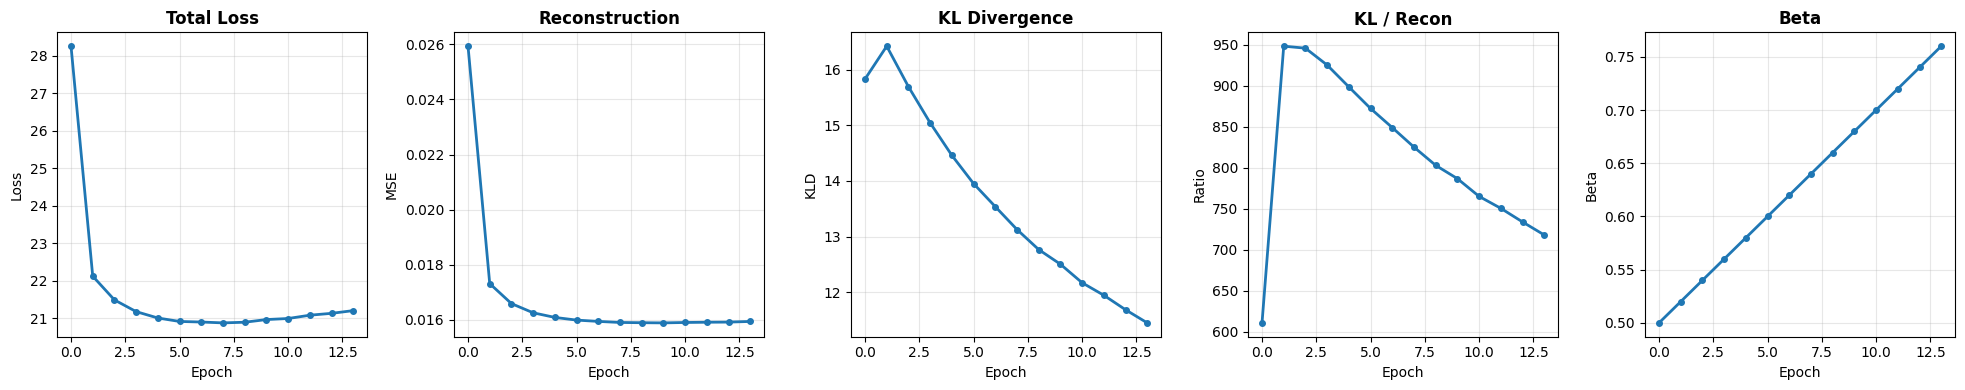


 Training complete! Final plots displayed above.


In [ ]:
trainer = pl.Trainer(
    accelerator='gpu',
    devices=[0],
    max_epochs=50,
    precision="32",
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, L_metrics_callback, early_stopping],
    log_every_n_steps=1
)



trainer.fit(module, data_module)

In [ ]:
trainer.save_checkpoint("model_vf.ckpt")


In [ ]:
cvae_model = CVAE(latent_dim=32, num_classes=10)


model_v1 = CVAELightningModule.load_from_checkpoint(
    '/content/model_vf.ckpt',
    model=cvae_model
)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:198: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [ ]:

test_loader = data_module.test_dataloader()
def diagnose_cvae_metrics_only(model, dataloader, device='cuda', num_batches=5):
    """
    CVAE diagnostic tool
    Though this assignment isn't based on metrics. This function helped quiete bit in previously understanding why the model has had a posterior collapse.
    In this current version of the notebook that issue has been resolved.

    """
    model.eval()

    all_mu = []
    all_logvar = []
    all_recon_loss = []
    all_recon_per_pixel = []
    all_kl_loss = []

    print("\n" + "="*60)
    print("          CVAE DIAGNOSTIC METRICS")
    print("="*60)

    # Collect statistics over multiple batches
    with torch.no_grad():
        for i, (x_batch, labels) in enumerate(dataloader):
            if i >= num_batches:
                break

            x_batch = x_batch.to(device)
            labels = labels.to(device)

            mu, logvar = model.model.encode(x_batch, labels)
            recon_x = model.model.decode(mu, labels)

            all_mu.append(mu)
            all_logvar.append(logvar)

            # Compute losses
            B = x_batch.size(0)
            num_pixels = x_batch.numel() // B

            # per-sample sum of squared errors (SSE), then mean across batch
            per_sample_sse = ((recon_x - x_batch) ** 2).view(B, -1).sum(dim=1)
            recon_sum_mean = per_sample_sse.mean()
            recon_per_pixel_mean = recon_sum_mean / float(num_pixels)

            # KL (sum over dims per sample, then mean over batch)
            kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            kl_loss = kl_per_sample.mean()

            # Store both representations
            all_recon_loss.append(recon_sum_mean.item())
            all_recon_per_pixel.append(recon_per_pixel_mean.item())
            all_kl_loss.append(kl_loss.item())

    # Concatenate all batches
    all_mu = torch.cat(all_mu, dim=0)
    all_logvar = torch.cat(all_logvar, dim=0)
    all_std = torch.exp(0.5 * all_logvar)

    # Per-dimension statistics
    mu_per_dim = all_mu.mean(dim=0)
    std_per_dim = all_std.mean(dim=0)
    kl_per_dim = -0.5 * (1 + all_logvar - all_mu.pow(2) - all_logvar.exp()).mean(dim=0)

    dim_total = std_per_dim.shape[0]
    dim_active_01 = (std_per_dim > 0.1).sum().item()
    dim_active_05 = (std_per_dim > 0.5).sum().item()
    dim_active_09 = (std_per_dim > 0.9).sum().item()

    avg_recon = np.mean(all_recon_loss)
    avg_recon_per_pixel = np.mean(all_recon_per_pixel)
    avg_kl = np.mean(all_kl_loss)

    # 1. LATENT SPACE STATISTICS
    print("\n LATENT SPACE STATISTICS")
    print("-" * 60)
    print(f"{'Metric':<25} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
    print("-" * 60)
    print(f"{'mu':<25} {all_mu.mean().item():>8.4f}    {all_mu.std().item():>8.4f}    {all_mu.min().item():>8.4f}    {all_mu.max().item():>8.4f}")
    print(f"{'logvar':<25} {all_logvar.mean().item():>8.4f}    {all_logvar.std().item():>8.4f}    {all_logvar.min().item():>8.4f}    {all_logvar.max().item():>8.4f}")
    print(f"{'std (exp(0.5*logvar))':<25} {all_std.mean().item():>8.4f}    {all_std.std().item():>8.4f}    {all_std.min().item():>8.4f}    {all_std.max().item():>8.4f}")

    print("\n" + "-" * 60)
    print(f"Prior:     N(μ=0.0, σ=1.0)")
    print(f"Posterior: N(μ={all_mu.mean().item():.3f}, σ={all_std.mean().item():.3f})")

    # 2. DIMENSION ACTIVITY
    print("\n DIMENSION ACTIVITY")
    print("-" * 60)
    print(f"Dimensions with std > 0.1:  {dim_active_01}/{dim_total} ({100*dim_active_01/dim_total:.1f}%)")
    print(f"Dimensions with std > 0.5:  {dim_active_05}/{dim_total} ({100*dim_active_05/dim_total:.1f}%)")
    print(f"Dimensions with std > 0.9:  {dim_active_09}/{dim_total} ({100*dim_active_09/dim_total:.1f}%)")

    # 3. LOSS METRICS
    print("\n LOSS METRICS")
    print("-" * 60)
    print(f"Reconstruction Loss (MSE per-pixel):  {avg_recon_per_pixel:.6f}")
    print(f"Reconstruction Loss (sum per-sample): {avg_recon:.6f}")
    print(f"KL Divergence (total):                {avg_kl:.6f}")
    print(f"KL Divergence (per dim):              {avg_kl/dim_total:.6f}")
    print(f"Loss Ratio (KL / Recon per-sample):  {avg_kl/(avg_recon + 1e-12):.2f}")

    # 4. DISTRIBUTION METRICS
    print("\n DISTRIBUTION METRICS")
    print("-" * 60)
    mu_skewness = ((all_mu - all_mu.mean()) ** 3).mean() / (all_mu.std() ** 3)
    mu_kurtosis = ((all_mu - all_mu.mean()) ** 4).mean() / (all_mu.std() ** 4)

    print(f"mu skewness:               {mu_skewness.item():>8.4f}")
    print(f"mu kurtosis:               {mu_kurtosis.item():>8.4f}")
    print(f"std per-dim (min):         {std_per_dim.min().item():.4f}")
    print(f"std per-dim (max):         {std_per_dim.max().item():.4f}")
    print(f"std per-dim (median):      {std_per_dim.median().item():.4f}")

    # 5. RECONSTRUCTION METRICS
    print("\n RECONSTRUCTION METRICS")
    print("-" * 60)
    x_sample, labels_sample = next(iter(dataloader))
    x_sample = x_sample[:8].to(device)
    labels_sample = labels_sample[:8].to(device)

    with torch.no_grad():
        mu_sample, logvar_sample = model.model.encode(x_sample, labels_sample)
        recon_sample = model.model.decode(mu_sample, labels_sample)

    sample_mse = F.mse_loss(recon_sample, x_sample, reduction='mean').item()
    pixel_errors = (recon_sample - x_sample).abs()

    print(f"Sample MSE:                {sample_mse:.6f}")
    print(f"Mean absolute error:       {pixel_errors.mean().item():.6f}")
    print(f"Max absolute error:        {pixel_errors.max().item():.6f}")

    # 6. GENERATION QUALITY TEST
    print("\n GENERATION QUALITY TEST")
    print("-" * 60)

    test_digit = 5
    num_gen_samples = 10

    z_samples = torch.randn(num_gen_samples, model.hparams.latent_dim, device=device)
    labels_gen = torch.full((num_gen_samples,), test_digit, device=device)

    with torch.no_grad():
        generated = model.model.decode(z_samples, labels_gen)

    diversity = 0
    count = 0
    for i in range(num_gen_samples):
        for j in range(i+1, num_gen_samples):
            diversity += (generated[i] - generated[j]).abs().mean().item()
            count += 1
    diversity /= count

    print(f"Generation diversity (digit {test_digit}): {diversity:.6f}")
    print(f"Target for good generation:   > 0.05")

    # 7. MODEL CONFIGURATION
    print("\n  MODEL CONFIGURATION")
    print("-" * 60)
    print(f"beta_kl:                   {model.hparams.beta_kl}")
    print(f"latent_dim:                {model.hparams.latent_dim}")
    print(f"num_classes:               {model.hparams.num_classes}")

    print("\n" + "="*60)

    return {
        'mu_mean': all_mu.mean().item(),
        'mu_std': all_mu.std().item(),
        'logvar_mean': all_logvar.mean().item(),
        'std_mean': all_std.mean().item(),
        'std_per_dim': std_per_dim.cpu(),
        'kl_per_dim': kl_per_dim.cpu(),
        'active_dims_01': dim_active_01,
        'active_dims_05': dim_active_05,
        'active_dims_09': dim_active_09,
        'total_dims': dim_total,
        'avg_recon_loss_per_sample': avg_recon,
        'avg_recon_loss_per_pixel': avg_recon_per_pixel,
        'avg_kl_loss': avg_kl,
        'avg_kl_per_dim': avg_kl/dim_total,
        'loss_ratio_per_sample': avg_kl/avg_recon,
        'sample_mse': sample_mse,
        'generation_diversity': diversity,
        'recon_sample': recon_sample.cpu(),
        'original_sample': x_sample.cpu(),
        'generated_sample': generated.cpu()
    }


results = diagnose_cvae_metrics_only(model_v1, test_loader, device='cuda', num_batches=5)


          CVAE DIAGNOSTIC METRICS

 LATENT SPACE STATISTICS
------------------------------------------------------------
Metric                    Mean         Std          Min          Max         
------------------------------------------------------------
mu                         -0.0059      0.7511     -2.9756      3.0077
logvar                     -1.2569      0.7864     -3.9149     -0.0976
std (exp(0.5*logvar))       0.5713      0.1902      0.1412      0.9524

------------------------------------------------------------
Prior:     N(μ=0.0, σ=1.0)
Posterior: N(μ=-0.006, σ=0.571)

 DIMENSION ACTIVITY
------------------------------------------------------------
Dimensions with std > 0.1:  32/32 (100.0%)
Dimensions with std > 0.5:  20/32 (62.5%)
Dimensions with std > 0.9:  0/32 (0.0%)

 LOSS METRICS
------------------------------------------------------------
Reconstruction Loss (MSE per-pixel):  0.009894
Reconstruction Loss (sum per-sample): 7.757081
KL Divergence (total):      

## Latent Space

The latent vector has a global mean near 0 which is in accordance to the normal distributions

Standar deviation of the posterior is lower than that of the prioir which means the latent space is concentrating the information without  completely collapsing.


## Dimension Activity
In short all latent dimensions are being utilized since their standard deviations is greater than one. 62.5% of dimensions have a std grater that 0.5 which means a good chunk of the latent space offers information.


Though all latent dimensions are being utlized just 62.5% are have a std greater than 0.5, and none are grater than 0.9 which is the ideal for a VAE, nonetheless the model reconstruct and generates pretty well (as seen below). The metrics show sing of posterior collapse eventhough the reconstruction are generation of images is satisfactory and not pure noise/ the same image.

This means that within those ~20 dimensions the model learned how to use them very efficiently and which appears to be sufficient  for this data set.

In short there seems to be a mild poosterior collapse that with perhaps a more complex data set would be hurlde but it does not seem to be problematic for MNIST.

## Loss Metrics

Recon loss is very low which suggest stable reconstructions and kl per dimesion is 0.59 which show that the model avoids deterministic reconstruction/generations, which was one of the issues on previous trials.

## Generation Capabilities

To evaluate the generation capablitiess  multiple samples of the same digit class were generated by decoding random latent vectors then they  were compared accross all pairs of generated images using pairwise absolute differences then average the differences across all pairs.

In short generate random image => Pass through decoder => compare.

This gave us that a diversity ratio of ~0.13 which shows diversity on the generated image.


Processing 64 images...
Labels: [9, 5, 6, 1, 9, 3, 6, 1]

CVAE RECONSTRUCTION VERIFICATION
Input shape:           torch.Size([64, 1, 28, 28])
Input range:           [0.0000, 1.0000]

Recon (det) shape:     torch.Size([64, 1, 28, 28])
Recon (det) range:     [0.0000, 0.9928]

Recon (sto) shape:     torch.Size([64, 1, 28, 28])
Recon (sto) range:     [0.0000, 0.9971]

MSE (deterministic):   0.010058
MSE (stochastic):      0.016269
MAE (deterministic):   0.038218
MAE (stochastic):      0.048799

Latent space stats:
  mu range:     [-2.8927, 3.0077]
  mu mean:      -0.0215
  logvar range: [-3.6856, -0.0976]
  logvar mean:  -1.2400

Sanity checks:
  Det == Input: False ✓ (should be False)
  Sto == Input: False ✓ (should be False)



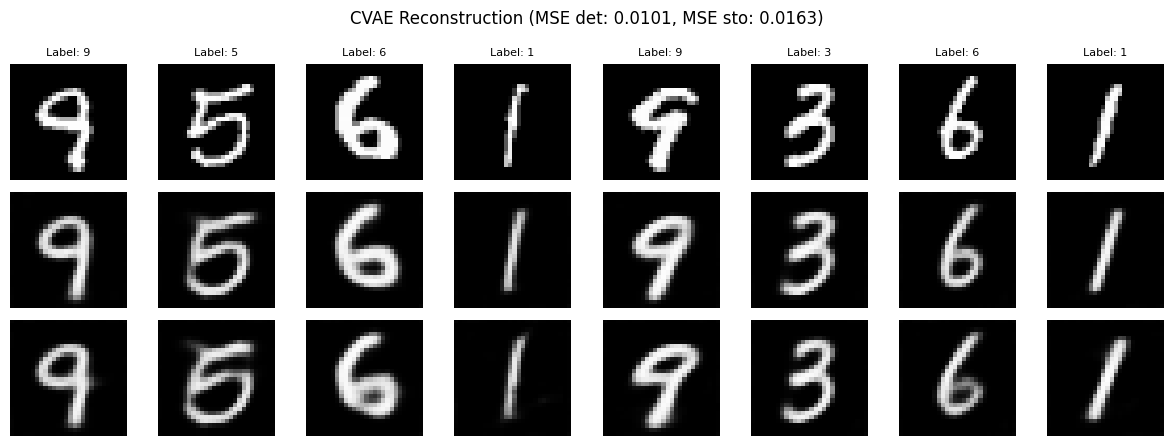

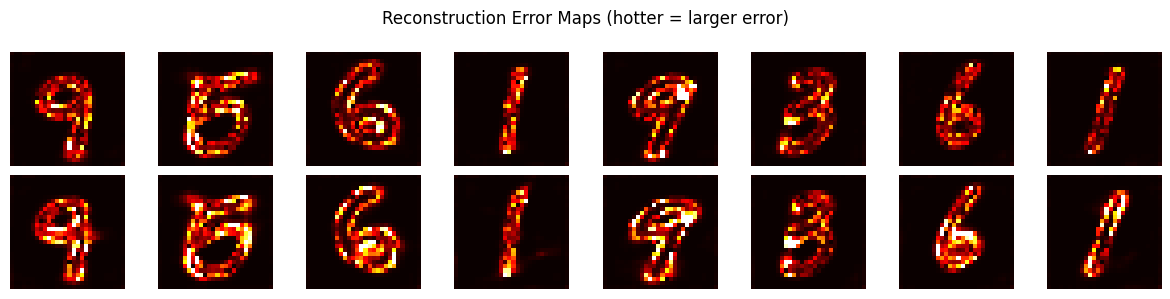

In [ ]:
test_loader = data_module.val_dataloader()
x_batch, labels = next(iter(test_loader))

device = "cuda" if torch.cuda.is_available() else "cpu"
model_v1.to(device)
x_batch = x_batch.to(device)
labels = labels.to(device)

print(f"Processing {x_batch.shape[0]} images...")
print(f"Labels: {labels[:8].tolist()}")

model_v1.eval()
with torch.no_grad():
    recon_x_stochastic, mu, logvar = model_v1(x_batch, labels)

    recon_x_deterministic = model_v1.model.decode(mu, labels)

print("\n" + "="*60)
print("CVAE RECONSTRUCTION VERIFICATION")
print("="*60)
print(f"Input shape:           {x_batch.shape}")
print(f"Input range:           [{x_batch.min().item():.4f}, {x_batch.max().item():.4f}]")
print(f"\nRecon (det) shape:     {recon_x_deterministic.shape}")
print(f"Recon (det) range:     [{recon_x_deterministic.min().item():.4f}, {recon_x_deterministic.max().item():.4f}]")
print(f"\nRecon (sto) shape:     {recon_x_stochastic.shape}")
print(f"Recon (sto) range:     [{recon_x_stochastic.min().item():.4f}, {recon_x_stochastic.max().item():.4f}]")

mse_det = F.mse_loss(recon_x_deterministic, x_batch).item()
mse_sto = F.mse_loss(recon_x_stochastic, x_batch).item()
mae_det = (recon_x_deterministic - x_batch).abs().mean().item()
mae_sto = (recon_x_stochastic - x_batch).abs().mean().item()

print(f"\nMSE (deterministic):   {mse_det:.6f}")
print(f"MSE (stochastic):      {mse_sto:.6f}")
print(f"MAE (deterministic):   {mae_det:.6f}")
print(f"MAE (stochastic):      {mae_sto:.6f}")

print(f"\nLatent space stats:")
print(f"  mu range:     [{mu.min().item():.4f}, {mu.max().item():.4f}]")
print(f"  mu mean:      {mu.mean().item():.4f}")
print(f"  logvar range: [{logvar.min().item():.4f}, {logvar.max().item():.4f}]")
print(f"  logvar mean:  {logvar.mean().item():.4f}")

are_identical_det = torch.allclose(recon_x_deterministic, x_batch, atol=1e-4)
are_identical_sto = torch.allclose(recon_x_stochastic, x_batch, atol=1e-4)

print(f"\nSanity checks:")
print(f"  Det == Input: {are_identical_det} ✓ (should be False)" if not are_identical_det else f"  Det == Input: {are_identical_det} ❌ (ERROR: identity mapping!)")
print(f"  Sto == Input: {are_identical_sto} ✓ (should be False)" if not are_identical_sto else f"  Sto == Input: {are_identical_sto} ❌ (ERROR: identity mapping!)")
print("="*60 + "\n")

x_batch_cpu = x_batch.cpu()
labels_cpu = labels.cpu()
recon_x_stochastic_cpu = recon_x_stochastic.cpu()
recon_x_deterministic_cpu = recon_x_deterministic.cpu()


num = 8
fig, axes = plt.subplots(3, num, figsize=(12, 4.5))

for i in range(num):
    # Original
    axes[0, i].imshow(x_batch_cpu[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Label: {labels_cpu[i]}", fontsize=8)

    # Reconstrucción determinística (mu)
    axes[1, i].imshow(recon_x_deterministic_cpu[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

    # Reconstrucción estocástica (mu + sigma * epsilon)
    axes[2, i].imshow(recon_x_stochastic_cpu[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=10, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel("Recon (μ)", fontsize=10, rotation=0, ha='right', va='center')
axes[2, 0].set_ylabel("Recon (z)", fontsize=10, rotation=0, ha='right', va='center')

plt.suptitle(f"CVAE Reconstruction (MSE det: {mse_det:.4f}, MSE sto: {mse_sto:.4f})", fontsize=12)
plt.tight_layout()
plt.show()

# Plot de diferencias (error maps)
fig, axes = plt.subplots(2, num, figsize=(12, 3))

for i in range(num):
    # Error determinístico
    error_det = (x_batch_cpu[i] - recon_x_deterministic_cpu[i]).abs().squeeze()
    axes[0, i].imshow(error_det, cmap='hot', vmin=0, vmax=0.5)
    axes[0, i].axis('off')

    # Error estocástico
    error_sto = (x_batch_cpu[i] - recon_x_stochastic_cpu[i]).abs().squeeze()
    axes[1, i].imshow(error_sto, cmap='hot', vmin=0, vmax=0.5)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Error (μ)", fontsize=10, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel("Error (z)", fontsize=10, rotation=0, ha='right', va='center')

plt.suptitle("Reconstruction Error Maps (hotter = larger error)", fontsize=12)
plt.tight_layout()
plt.show()

The purpose of this experiment was to  determine if the model was properly reconstructing or just recreating the input exactly as it was given (the images seemed too perfect).

Two ways of reconstructing the images were selected, deterministically and stochastically. In simpler words if given the same input will it generate the same image, or random reconstruction.

This is also seen on the heatmaps.

The deterministic row of the heatmap shows what the encoder's mean can achieve alone, while the stochastic row shows that adding noise  maintains that quality while unlocking generative capabilities.

Since both images are very similar yet not equal it seems my CVAE can accurately reconstruct and generete well.

(the other metrics in the print are not explained since the most relevant ones were explained on the prior cell).




In [ ]:
torch.serialization.add_safe_globals([
    CVAE
])


In [ ]:
model = CVAELightningModule.load_from_checkpoint('/content/model_vf.ckpt')


In [ ]:
def generate_variations(model, label, num_samples=8, device='cuda'):

    model.eval()
    model.to(device)

    z_samples = torch.randn(num_samples, model.hparams.latent_dim, device=device)
    labels = torch.full((num_samples,), label, dtype=torch.long, device=device)

    with torch.no_grad():
        generated = model.model.decode(z_samples, labels)

    generated_cpu = generated.cpu()

    fig, axes = plt.subplots(1,num_samples, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(num_samples):
        axes[i].imshow(generated_cpu[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f"Variation {i+1}", fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f"Generated variations of digit {label}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return generated_cpu


device = "cuda" if torch.cuda.is_available() else "cpu"

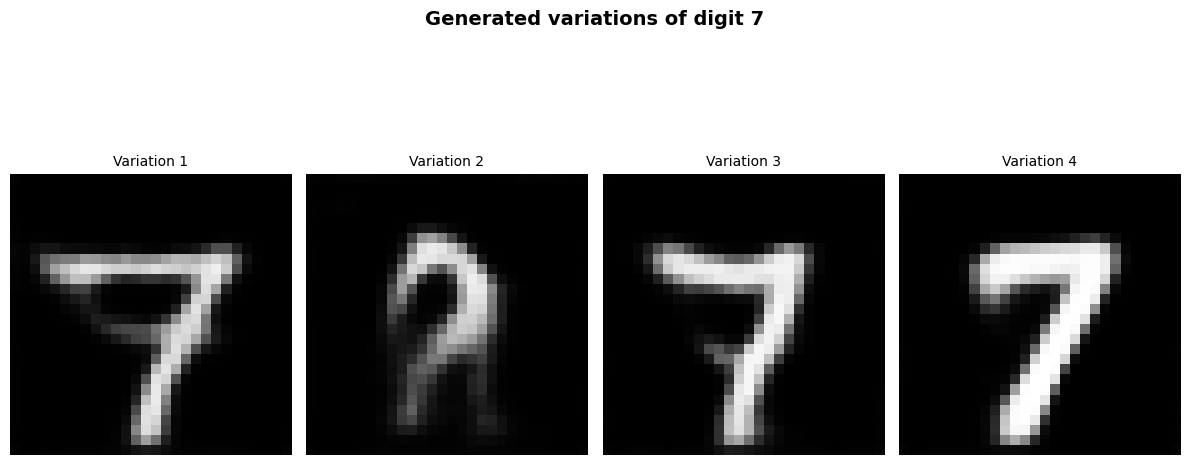

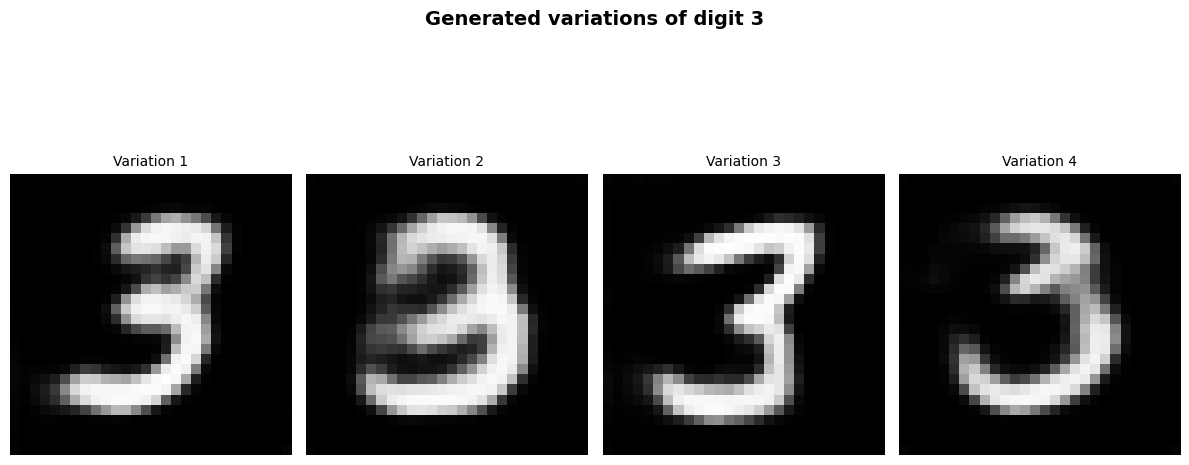

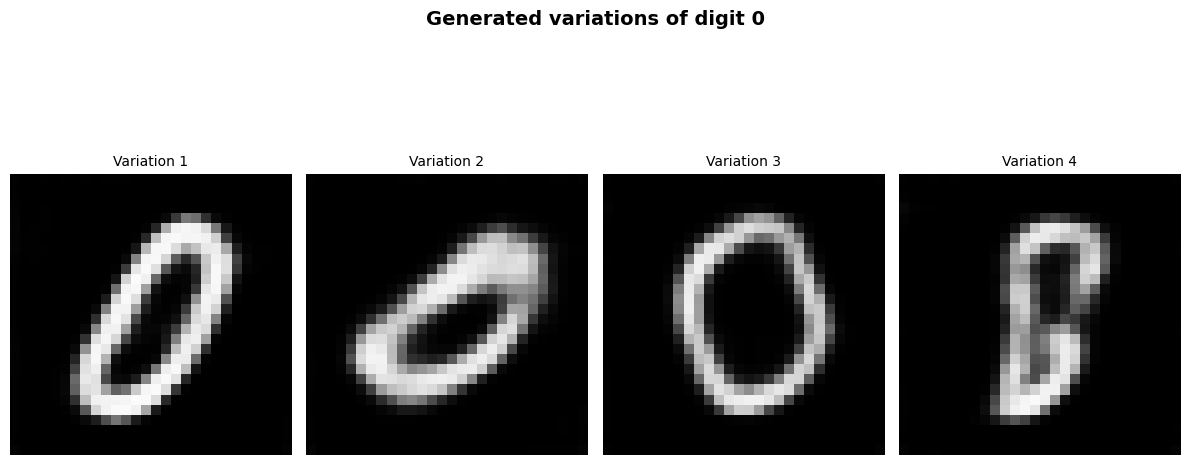

tensor([[[[7.1555e-03, 1.6448e-03, 2.0838e-03,  ..., 2.6363e-03,
           2.0703e-03, 5.6047e-03],
          [1.5214e-03, 1.7511e-04, 2.2992e-04,  ..., 1.4386e-04,
           1.2785e-04, 6.5218e-04],
          [3.9113e-03, 5.5423e-04, 7.7836e-04,  ..., 8.4056e-05,
           7.9352e-05, 3.1386e-04],
          ...,
          [4.2091e-03, 4.1373e-04, 4.3225e-04,  ..., 1.6159e-03,
           1.8467e-03, 6.9783e-03],
          [3.7241e-03, 2.5471e-04, 2.0410e-04,  ..., 1.0062e-03,
           1.1727e-03, 4.8578e-03],
          [1.1818e-02, 1.8073e-03, 1.7587e-03,  ..., 2.3470e-03,
           3.4264e-03, 1.4693e-02]]],


        [[[6.8059e-03, 1.6114e-03, 1.0995e-03,  ..., 5.7127e-03,
           3.5898e-03, 8.6967e-03],
          [9.6855e-04, 1.0491e-04, 1.0025e-04,  ..., 6.8735e-04,
           3.8725e-04, 1.3493e-03],
          [1.5721e-03, 2.0019e-04, 2.4327e-04,  ..., 5.6525e-04,
           3.0397e-04, 7.4380e-04],
          ...,
          [5.8975e-03, 8.2331e-04, 4.4788e-04,  ..., 6.30

In [ ]:


# Generate variations of digit 7
generate_variations(model_v1, label=7, num_samples=4, device=device)

# Generate variations of digit 3
generate_variations(model_v1, label=3, num_samples=4, device=device)

# Generate variations of digit 0
generate_variations(model_v1, label=0, num_samples=4, device=device)

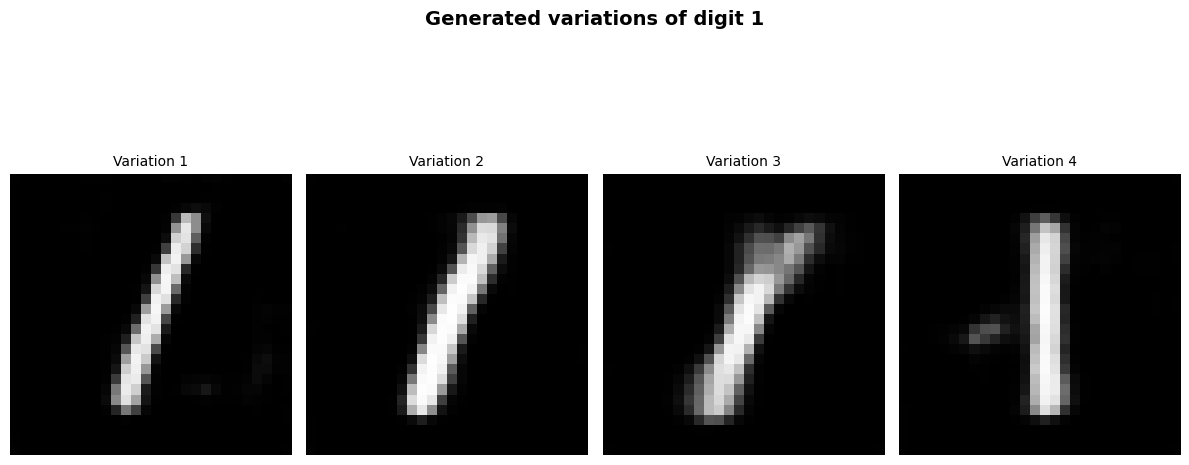

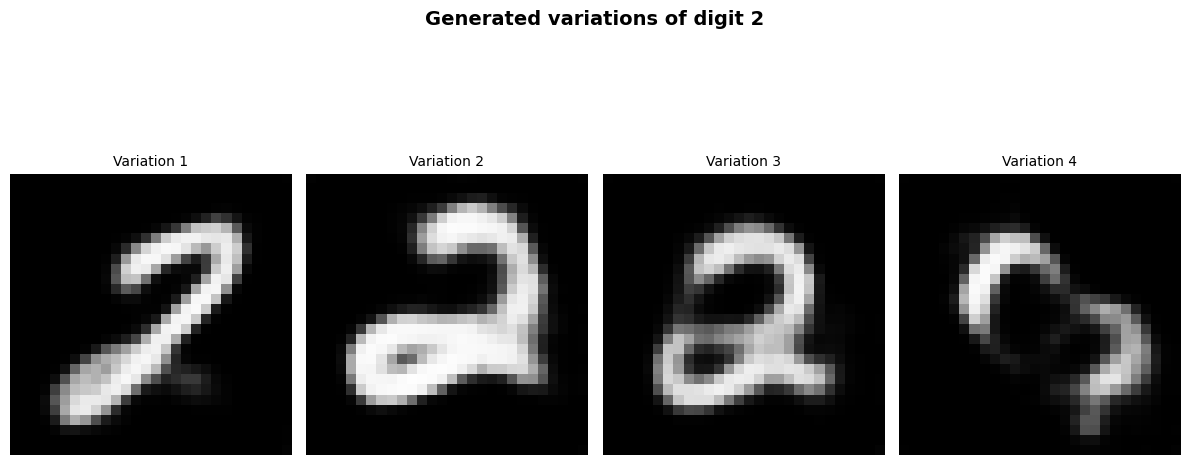

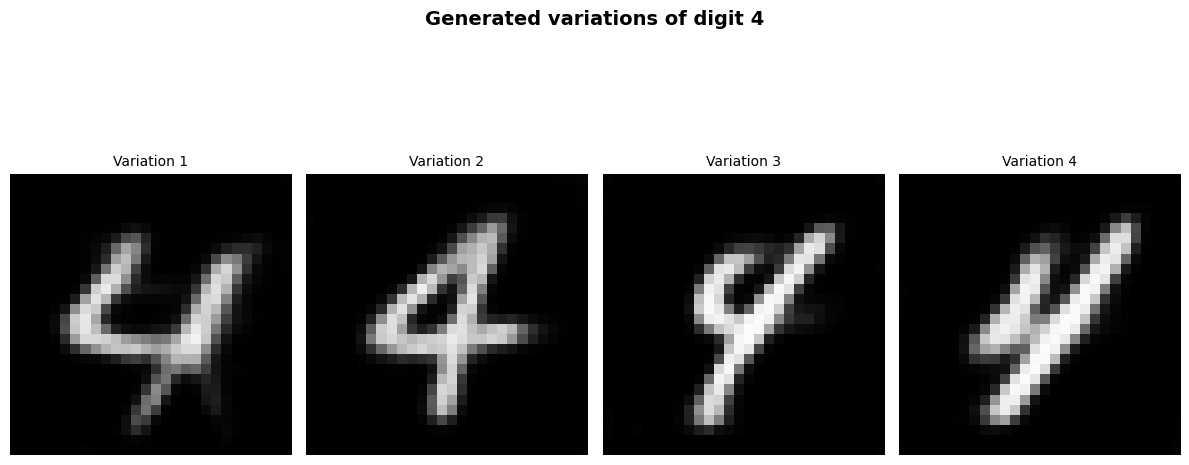

tensor([[[[2.3870e-03, 2.9560e-04, 3.1250e-04,  ..., 1.9211e-03,
           2.9159e-03, 9.3982e-03],
          [2.7777e-04, 1.4403e-05, 1.0479e-05,  ..., 4.1327e-04,
           5.4355e-04, 2.5705e-03],
          [4.7374e-04, 4.9211e-05, 2.8766e-05,  ..., 7.4765e-04,
           7.5248e-04, 2.2502e-03],
          ...,
          [2.6500e-03, 3.8350e-04, 3.9808e-04,  ..., 2.6741e-04,
           1.3783e-04, 9.2535e-04],
          [2.9597e-03, 3.4431e-04, 2.5657e-04,  ..., 1.4112e-04,
           1.0170e-04, 1.2194e-03],
          [5.8454e-03, 1.1758e-03, 1.1974e-03,  ..., 5.3820e-04,
           9.3368e-04, 7.0354e-03]]],


        [[[2.6147e-03, 4.7525e-04, 6.8502e-04,  ..., 1.0368e-02,
           1.2611e-02, 2.1306e-02],
          [6.0918e-04, 6.1484e-05, 3.7905e-05,  ..., 3.3321e-03,
           3.3952e-03, 8.7298e-03],
          [1.6850e-03, 2.8967e-04, 1.5804e-04,  ..., 2.8741e-03,
           2.6224e-03, 8.8036e-03],
          ...,
          [4.2236e-03, 5.5171e-04, 4.0976e-04,  ..., 1.16

In [ ]:
generate_variations(model_v1, label=1, num_samples=4, device=device)
generate_variations(model_v1, label=2, num_samples=4, device=device)
generate_variations(model_v1, label=4, num_samples=4, device=device)


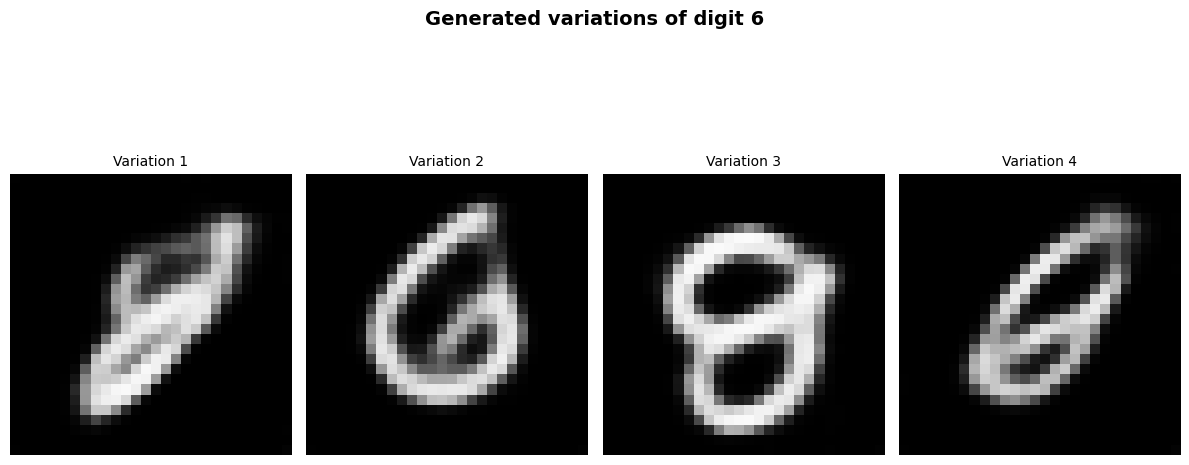

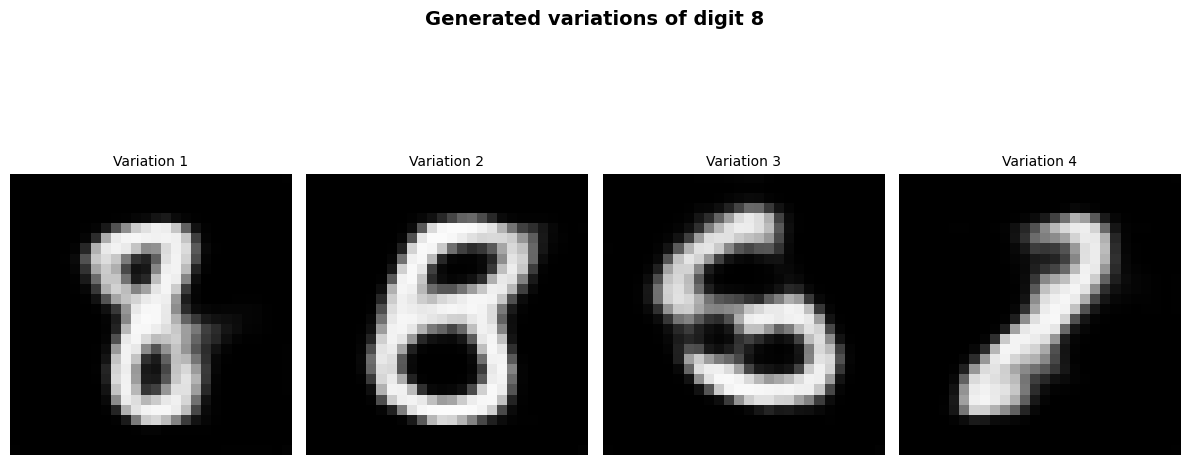

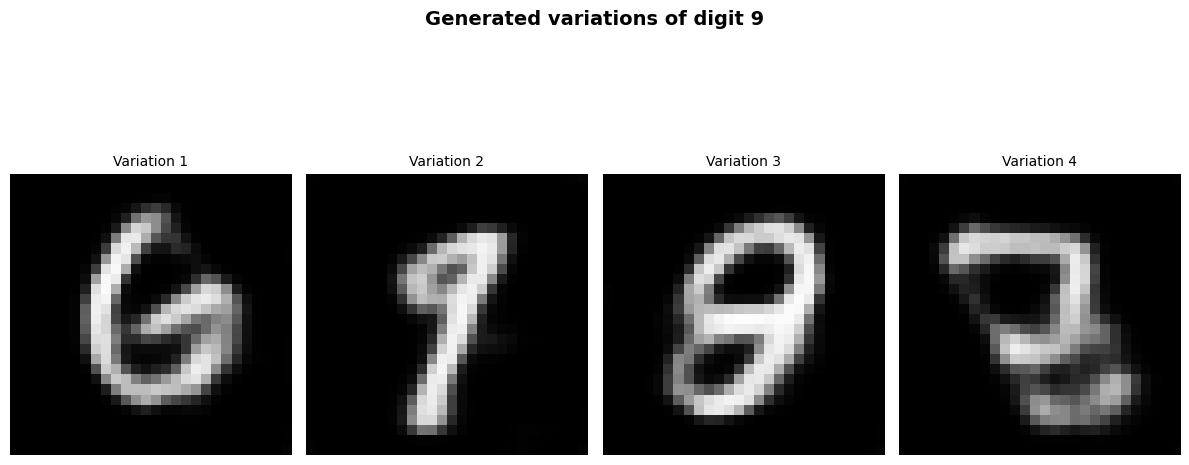

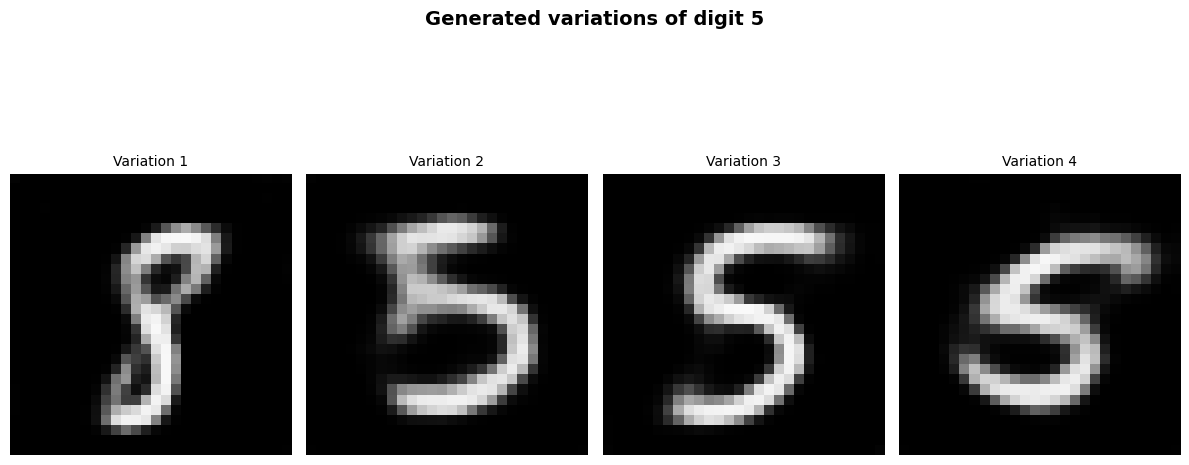

tensor([[[[1.2482e-02, 2.2776e-03, 1.2656e-03,  ..., 1.1141e-02,
           5.6987e-03, 8.0474e-03],
          [2.7177e-03, 3.5829e-04, 2.2041e-04,  ..., 2.4248e-03,
           7.3823e-04, 1.7166e-03],
          [2.4801e-03, 6.2407e-04, 7.1385e-04,  ..., 4.0313e-03,
           1.0871e-03, 2.0805e-03],
          ...,
          [1.8497e-03, 2.4556e-04, 2.4539e-04,  ..., 3.1200e-04,
           2.8728e-04, 1.0980e-03],
          [1.0864e-03, 1.0849e-04, 9.2851e-05,  ..., 2.3115e-04,
           2.5381e-04, 1.3855e-03],
          [2.7694e-03, 6.6068e-04, 8.5573e-04,  ..., 7.9420e-04,
           1.1670e-03, 5.6061e-03]]],


        [[[9.2093e-03, 1.0130e-03, 9.0069e-04,  ..., 6.6126e-04,
           5.6641e-04, 1.8929e-03],
          [1.5111e-03, 8.3347e-05, 6.9111e-05,  ..., 2.3290e-05,
           1.5182e-05, 1.5974e-04],
          [1.3507e-03, 8.9467e-05, 6.3248e-05,  ..., 3.7631e-05,
           2.0276e-05, 1.4422e-04],
          ...,
          [1.4725e-03, 2.5692e-04, 4.2514e-04,  ..., 5.43

In [ ]:
generate_variations(model_v1, label=6, num_samples=4, device=device)
generate_variations(model_v1, label=8, num_samples=4, device=device)
generate_variations(model_v1, label=9, num_samples=4, device=device)
generate_variations(model_v1, label=5, num_samples=4, device=device)

When it comes to generation the model does well (realtively, since some of the numbers are questinables) on numbers 0 ,1, 2, 3, 4,and 7, and somewhat well on 5 and 8. On numbers 6 and 9 the model has some limitations.

On digit 9 it seems to generate a correcct 9 one or two times out of four, it seems to generate a nine very similar to a six in a way. Well if we look at variation 2 of the sixes and variation 1 of the nines it generated practically the same images. This can also be seen to a lesser extent in variation 4 of the nines and variaation 3 of the sixes.

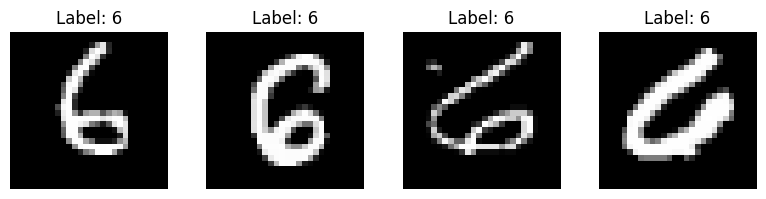

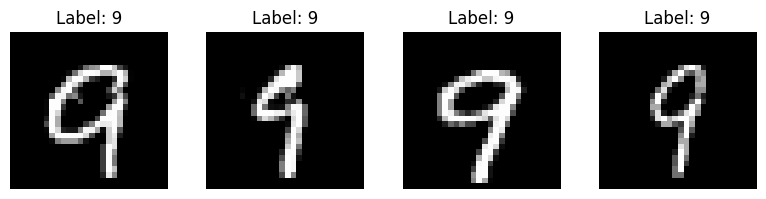

In [ ]:
def plot_mnist_samples(data_module, label, num_samples=4):


    data_module.setup(stage="fit")
    dataset = data_module.mnist_train

    samples = []
    for img, lbl in dataset:
        if lbl == label:
            samples.append(img)
            if len(samples) >= num_samples:
                break

    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples * 2, 2))
    for i, ax in enumerate(axes):
        if i < len(samples):
            ax.imshow(samples[i].squeeze(), cmap='gray')
            ax.axis('off')
            ax.set_title(f'Label: {label}')

    plt.tight_layout()
    plt.show()

    return samples
six= plot_mnist_samples(data_module, label=6, num_samples=4)
nine= plot_mnist_samples(data_module, label=9, num_samples=4)



In a way the six is just a rotation of a nine.

The latent space of this model is very compressed and seems to work for most classes, nonetheless since these two numbers are similar, and are drawn in a way similar to other numbers, these might make them very near other numbers in the latent space. This might also be the case since the label embedding collpases the 10 classes into 2 dimensions which may make it harder for the model to generate variations that are similar yet different from eachother. One of the earlier issues before arriving to this model was that the label embedding was to powerful, it was 10 dimensions, which made very clear genertions, but the latent space was being ignored by the decoder and it relied heavily on the class embedding.

In hindsight a 2 dimension might have been way too restrictive.

In [ ]:
class CVAE2(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10):
        super(CVAE2, self).__init__()

        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.label_embedding = nn.Embedding(num_classes, 7)
        """
        The main difference between this module and the previous one is the use of a 7-dimensional label embedding. Increasing the embedding dimensionality
        allows the model to encode richer information about the conditional label, which can be more effectively used into the latent representation
        during generation.
        The encoder and decoder architectures remain unchanged.
        """

        def get_encoder_block(input_channels, output_channels):
            return [
                nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2),
            ]


        self.encoder = nn.Sequential(
            *get_encoder_block(8, 32),
            *get_encoder_block(32, 64),
            *get_encoder_block(64, 128),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        self.fc_decode = nn.Linear(latent_dim + 7, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x, labels):
        batch_size = x.size(0)

        label_embed = self.label_embedding(labels)
        label_spatial = label_embed.view(batch_size, 7, 1, 1).expand(-1, -1, 28, 28)

        x_conditional = torch.cat([x, label_spatial], dim=1)
        encoded = self.encoder(x_conditional)

        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        return mu, logvar

    def decode(self, z, labels):
        label_embed = self.label_embedding(labels)
        z_conditional = torch.cat([z, label_embed], dim=1)
        decoded = self.fc_decode(z_conditional)
        decoded = self.decoder(decoded)
        return decoded

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self._reparameterize(mu, logvar)
        decoded = self.decode(z, labels)
        return decoded, mu, logvar

    def _reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

In [ ]:

module = CVAELightningModule(
    model=CVAE2(),
    latent_dim=32,
    num_classes=10,
    beta_kl=1.0,
    min_beta=0.5,
    warmup_epochs=25,
)
data_module = MNISTDataModule()
data_module.setup()

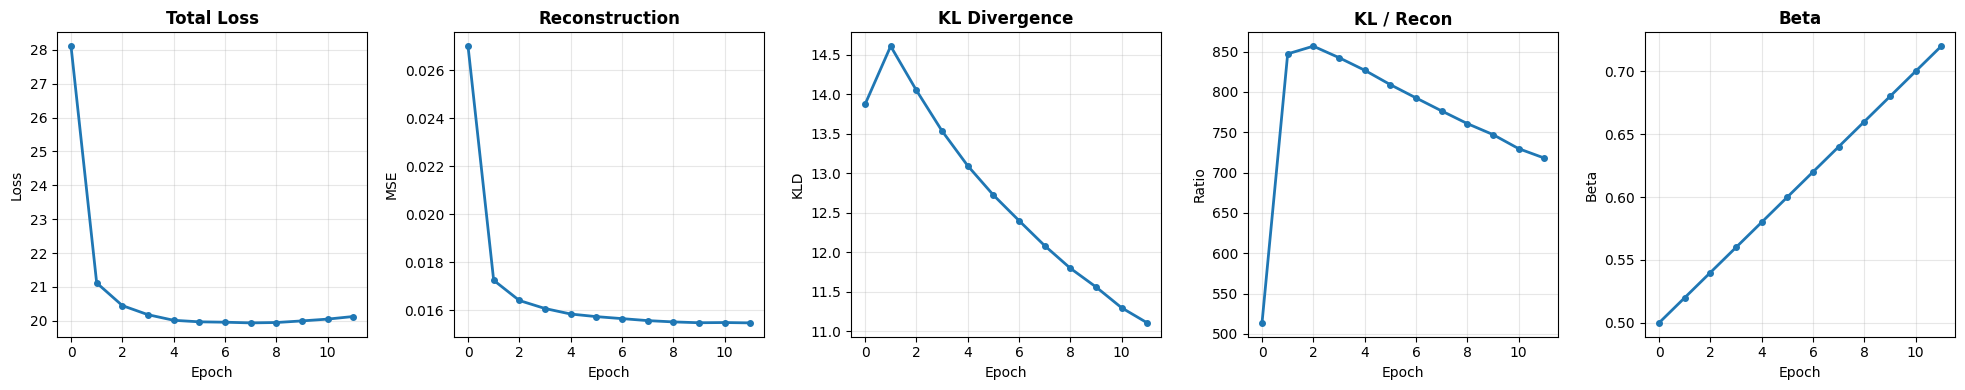


 Training complete! Final plots displayed above.


In [ ]:
trainer = pl.Trainer(
    accelerator='gpu',
    devices=[0],
    max_epochs=50,
    precision="32",
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, L_metrics_callback, early_stopping],
    log_every_n_steps=1
)



trainer.fit(module, data_module)

In [ ]:
torch.serialization.add_safe_globals([
    CVAE2
])


In [ ]:
model_v2 = CVAELightningModule.load_from_checkpoint(
    '/content/model_v2.ckpt',
    weights_only=False
)


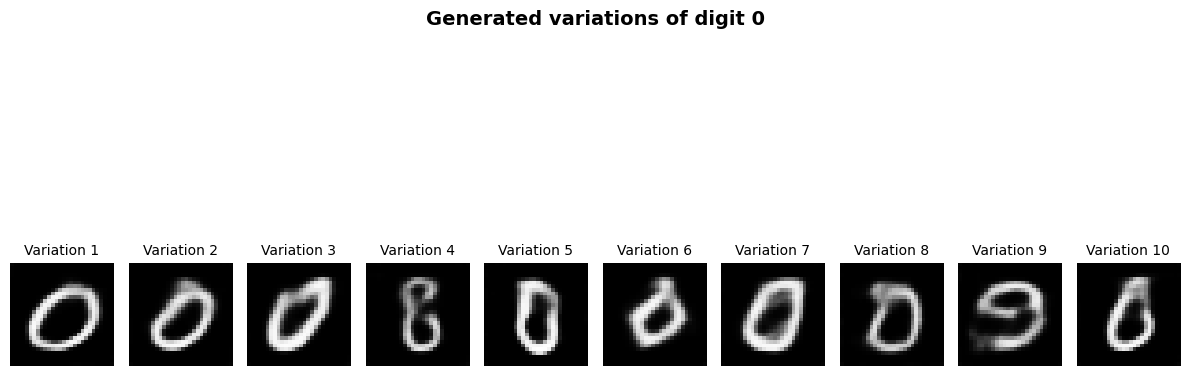

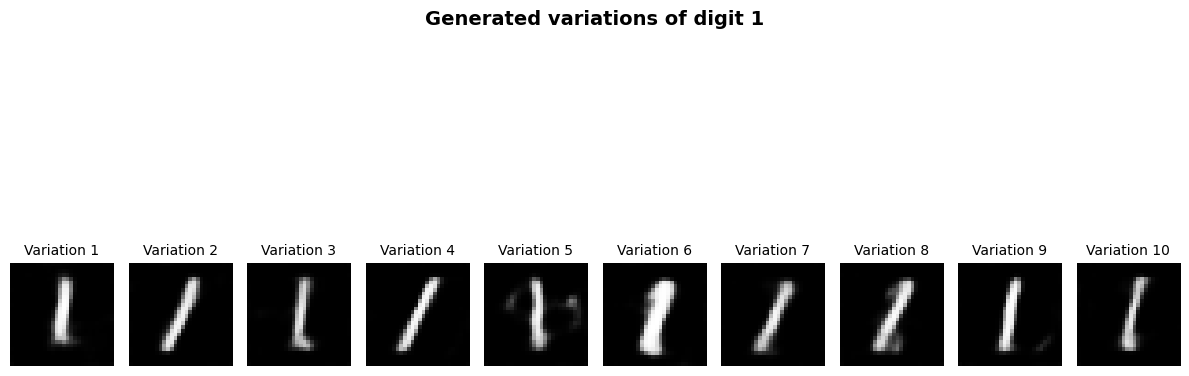

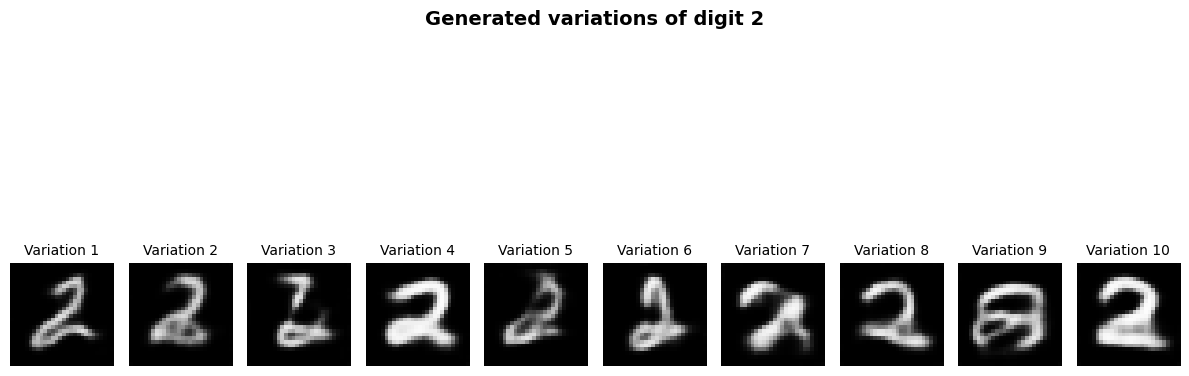

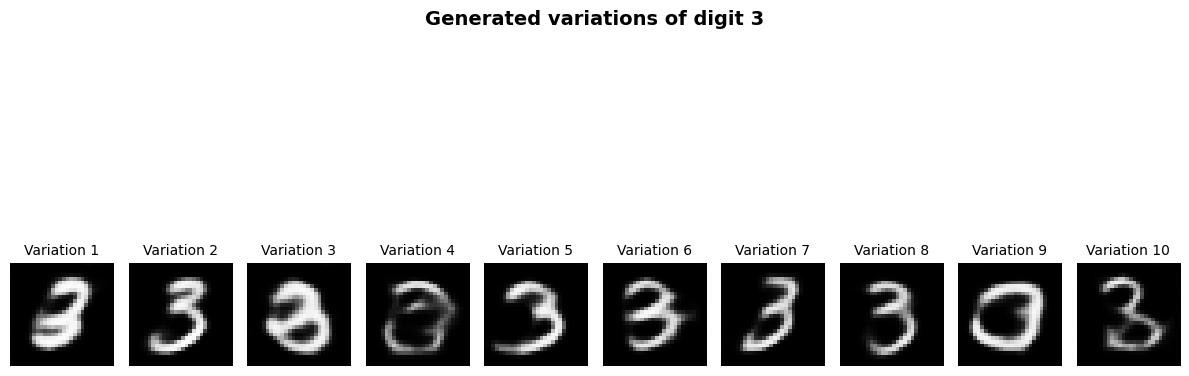

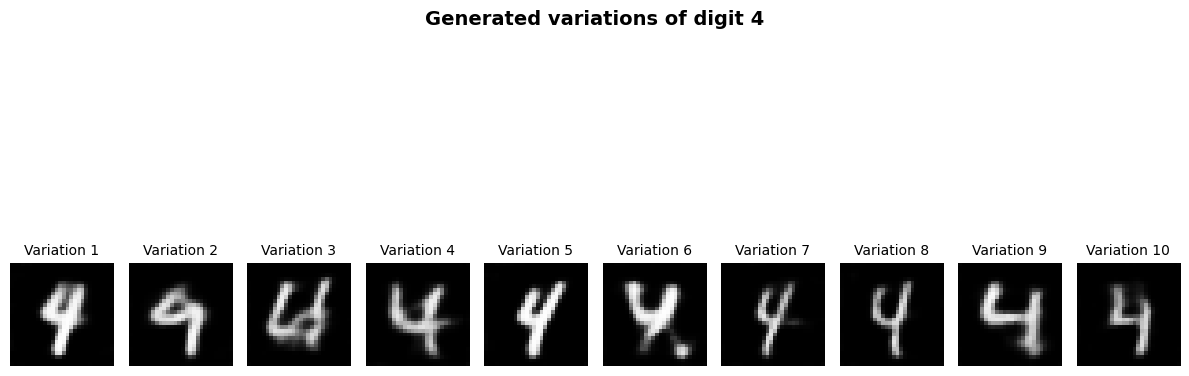

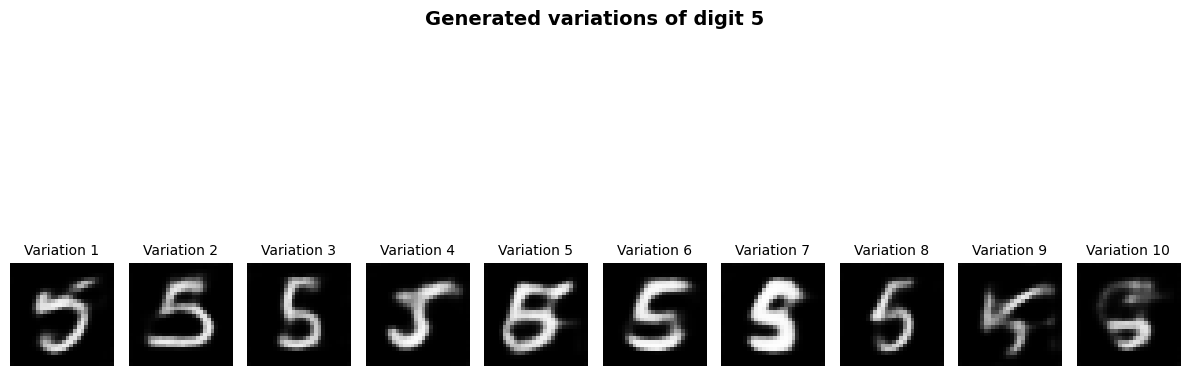

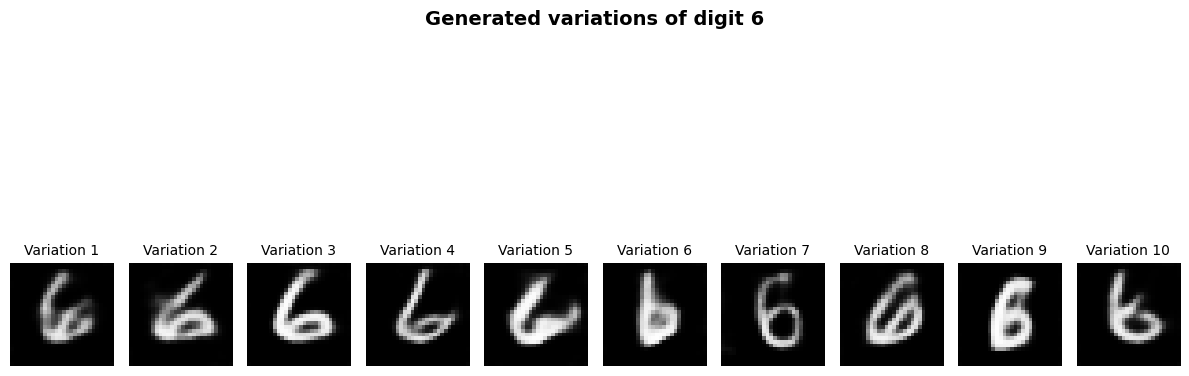

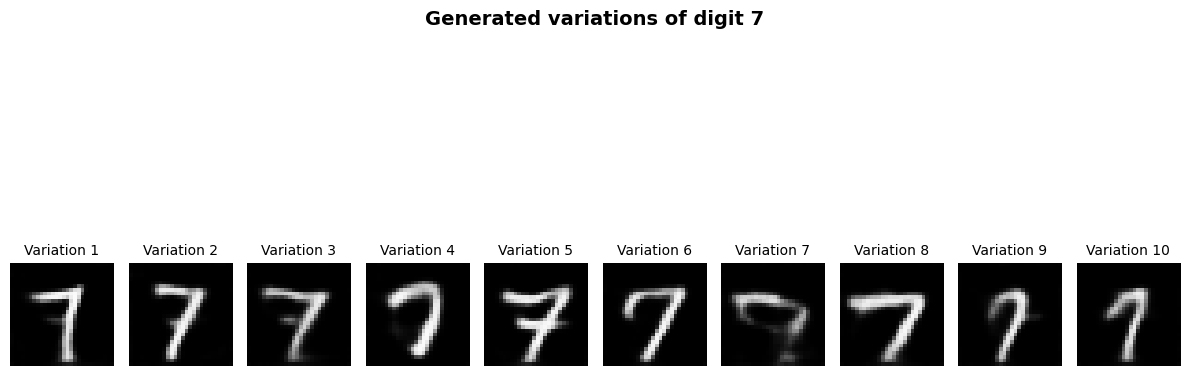

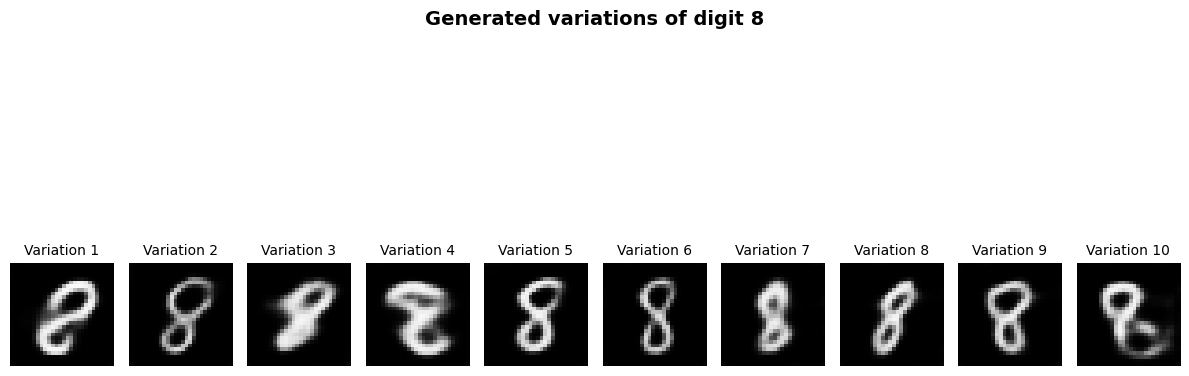

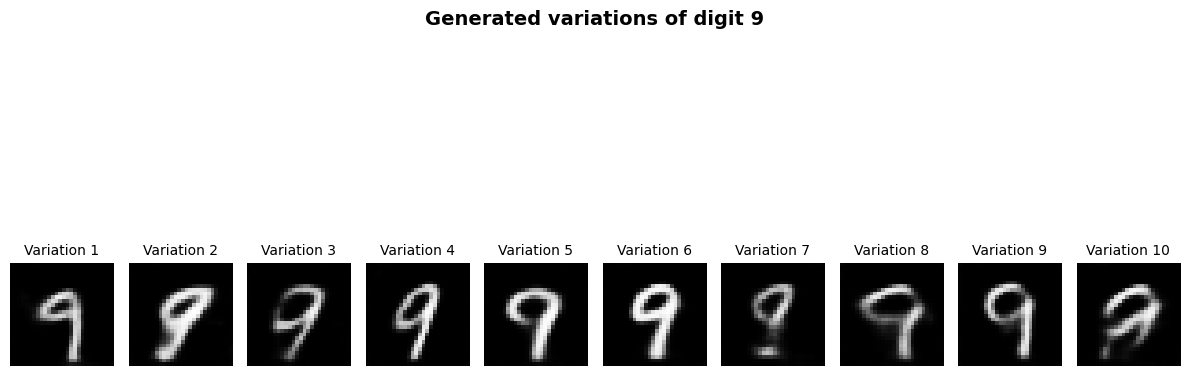

In [ ]:
for r in range(10):
  x = generate_variations(model_v2, label=r, num_samples=10, device=device)

With a 7-dimensional label embedding, the generated digits appear clearer overall; however, they still lack sharp definition. This residual fuzziness can be attributed to the regularizing effect of the KL divergence, which encourages a smooth latent space at the expense of fine-grained detail

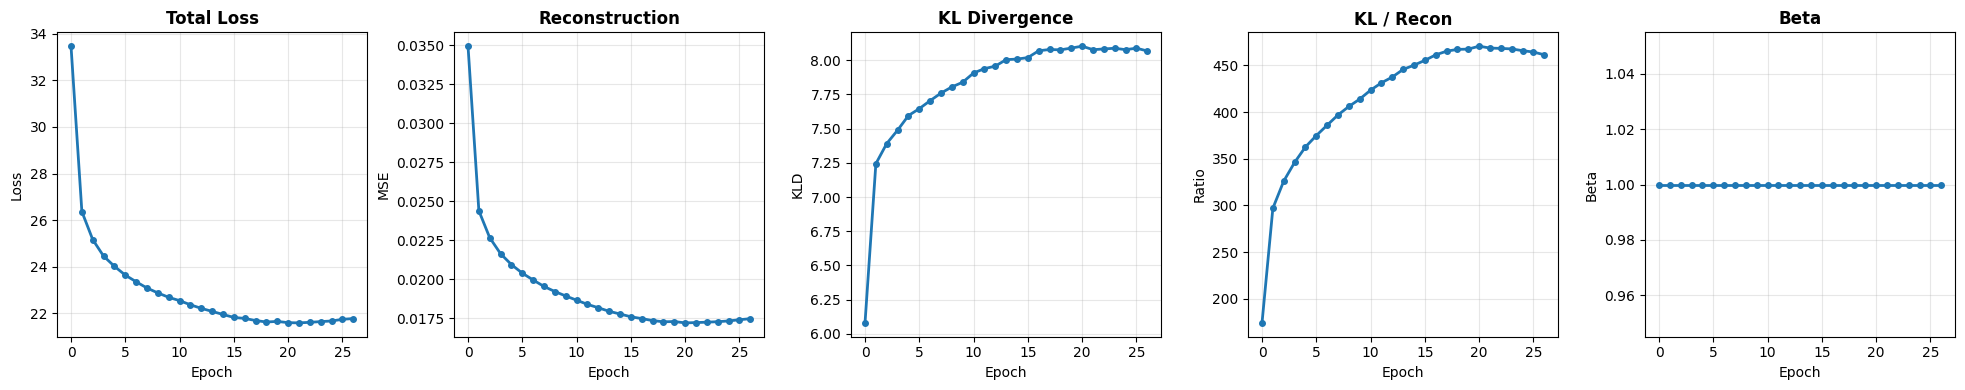


 Training complete! Final plots displayed above.


In [ ]:
module = CVAELightningModule(
    model=CVAE2(),
    latent_dim=32,
    num_classes=10,
    beta_kl=1.0,
    min_beta=1,
    warmup_epochs=25,
)
data_module = MNISTDataModule()
data_module.setup()

trainer = pl.Trainer(
    accelerator='gpu',
    devices=[0],
    max_epochs=50,
    precision="32",
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, L_metrics_callback, early_stopping],
    log_every_n_steps=1
)



trainer.fit(module, data_module)

In [ ]:
model_v3 = CVAELightningModule.load_from_checkpoint('/content/model_v3.ckpt')

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:198: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


When beta was fixed to 1 throughout training, the model produced more coherent and  images. This suggests that a stable KL regularization helped reduce latent noise and training instability, improving perceptual quality despite the inherent smoothing effect of the KL term on reconstructions.

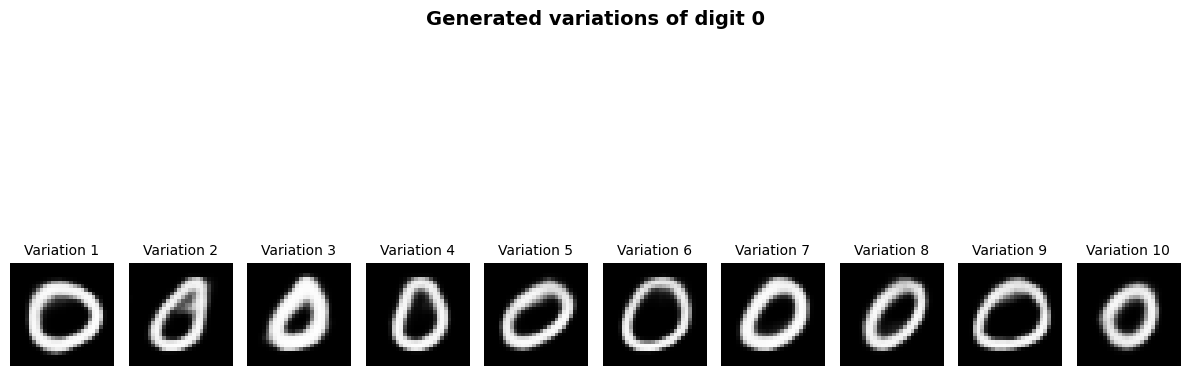

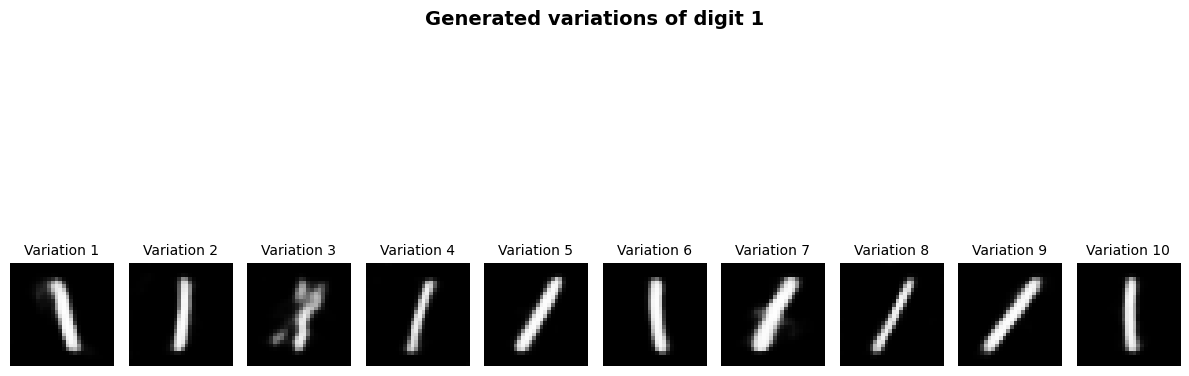

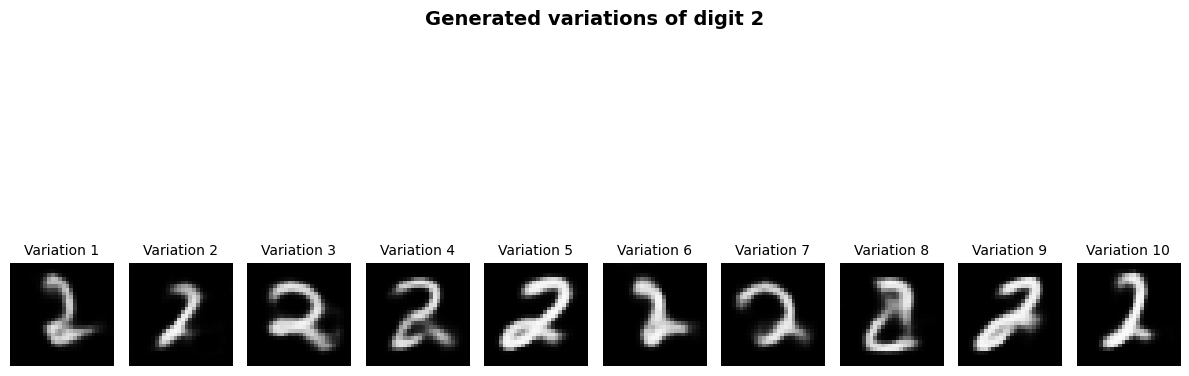

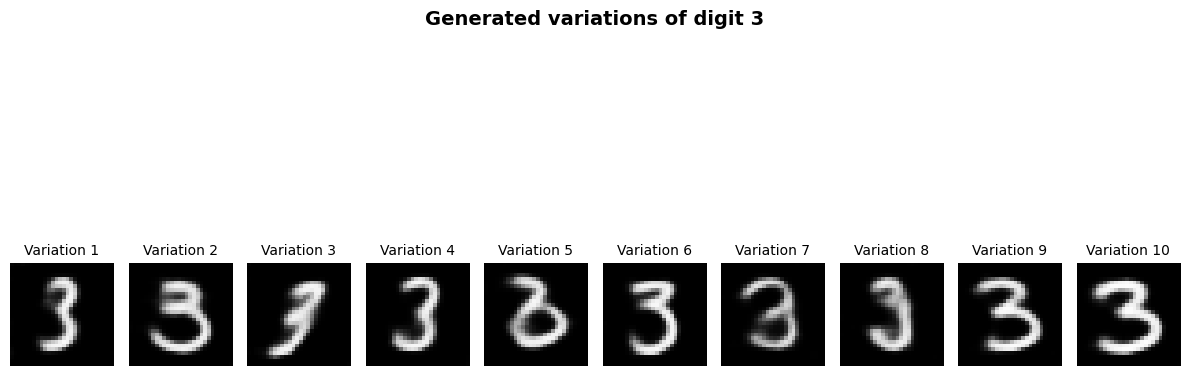

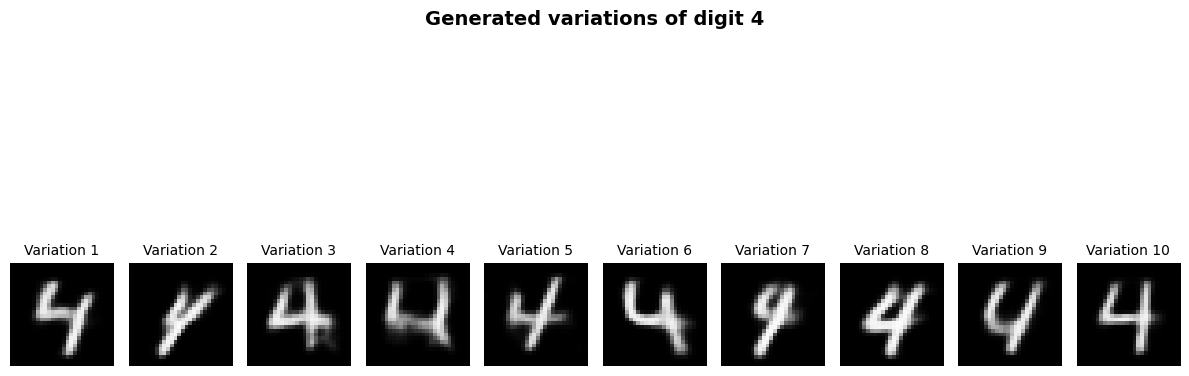

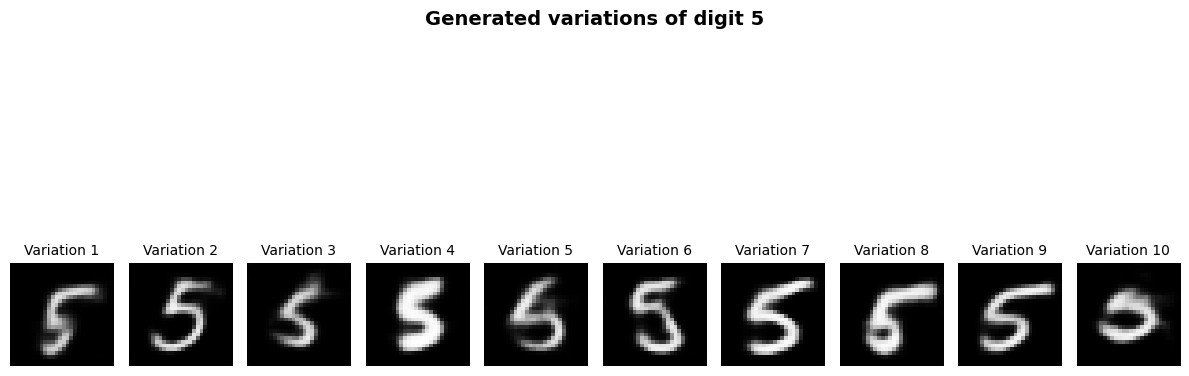

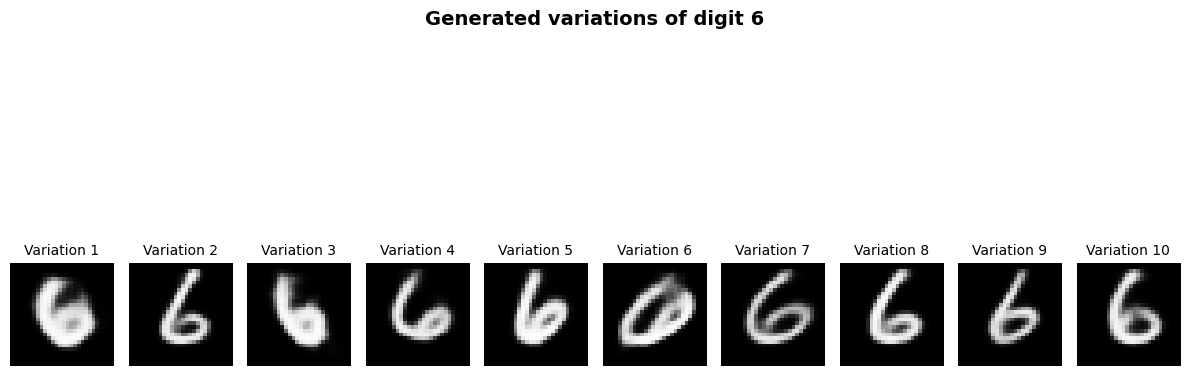

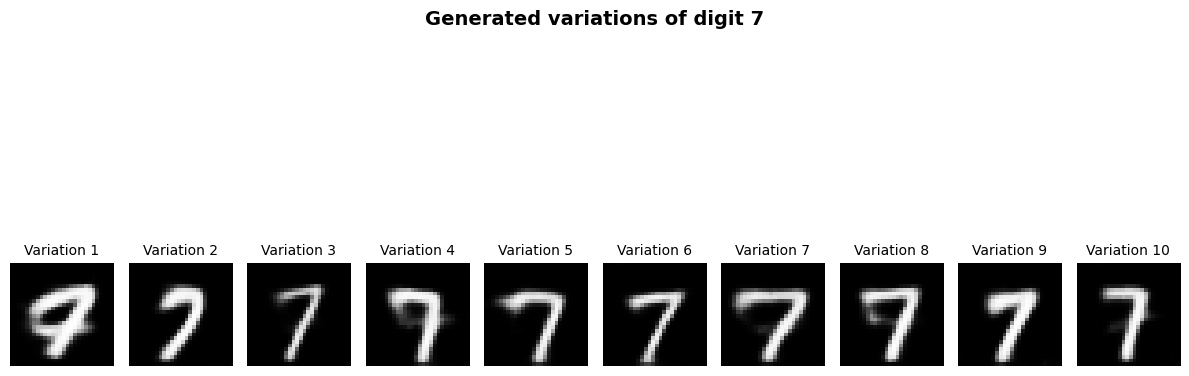

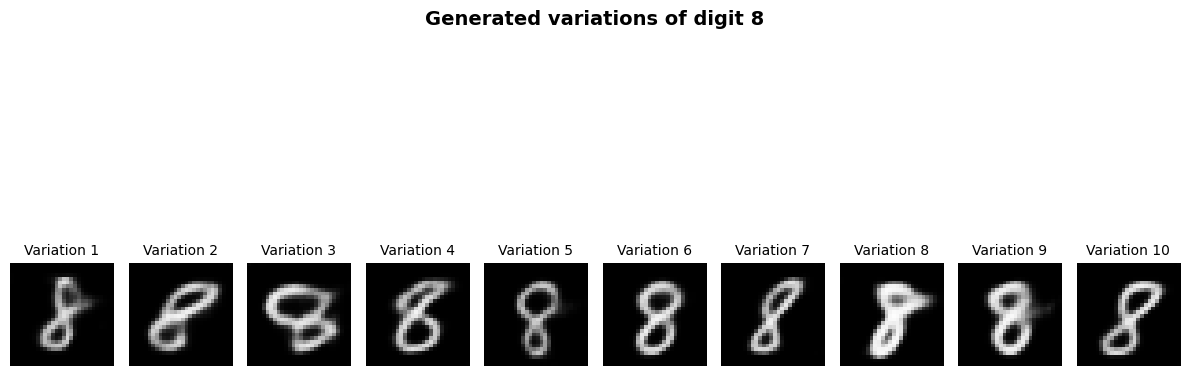

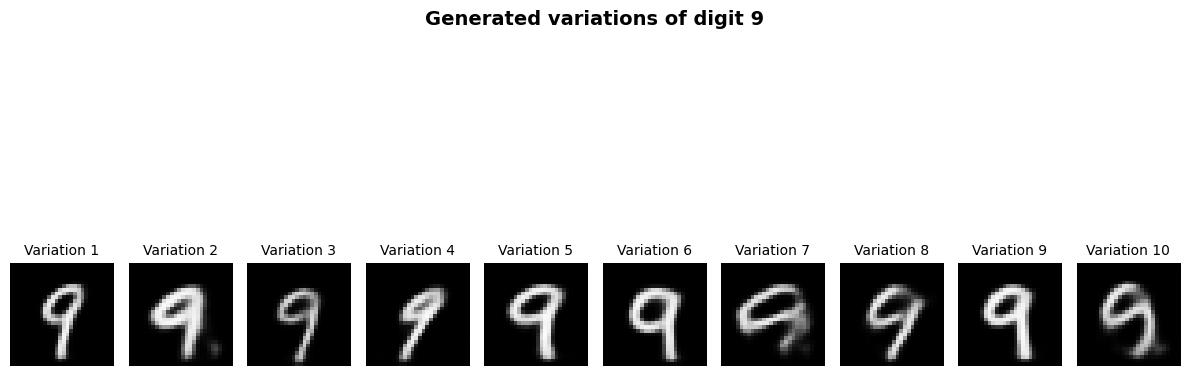

In [ ]:
for r in range(10):
  x = generate_variations(model_v3, label=r, num_samples=10, device=device)

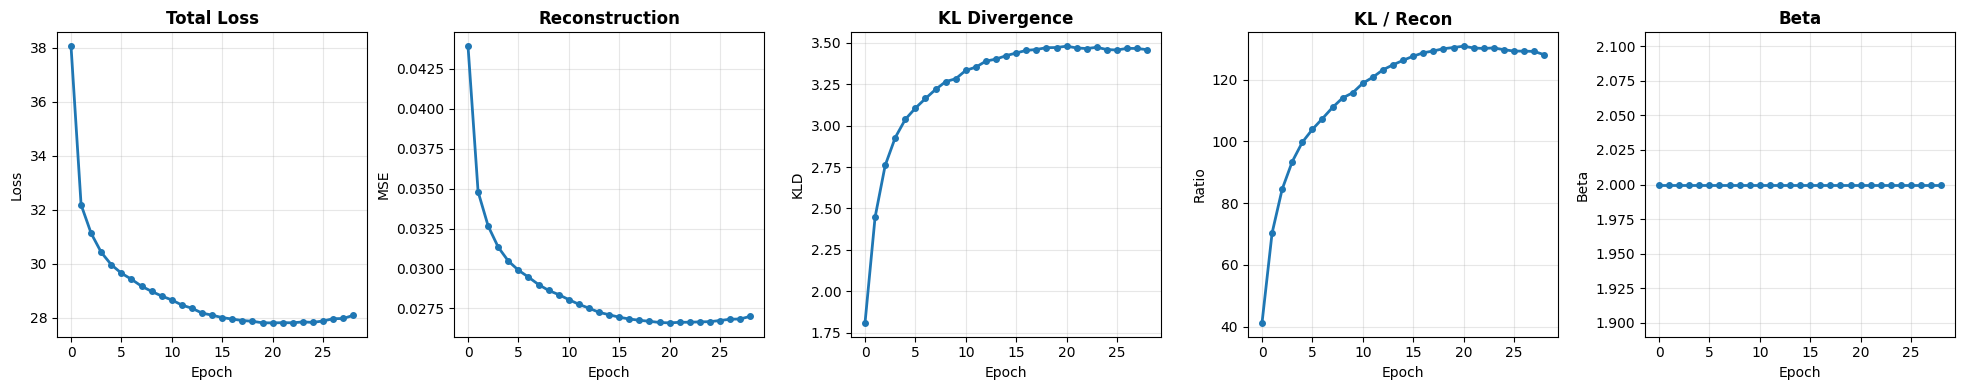


 Training complete! Final plots displayed above.


In [ ]:
module = CVAELightningModule(
    model=CVAE2(),
    latent_dim=32,
    num_classes=10,
    beta_kl=2.0,
    min_beta=2,
    warmup_epochs=25,
)
data_module = MNISTDataModule()
data_module.setup()

trainer = pl.Trainer(
    accelerator='gpu',
    devices=[0],
    max_epochs=50,
    precision="32",
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, L_metrics_callback, early_stopping],
    log_every_n_steps=1
)



trainer.fit(module, data_module)

Increasing beta from 1 to 2 led to  blurrier generations. This behavior indicates over-regularization of the latent space, as the stronger KL penalty constrained the encoder to produce latent representations closer to the prior (p
(z)=N(0,I)), thereby limiting the amount of detailed information available for reconstruction.

In [ ]:
model_v4 = CVAELightningModule.load_from_checkpoint('/content/model_v4.ckpt')


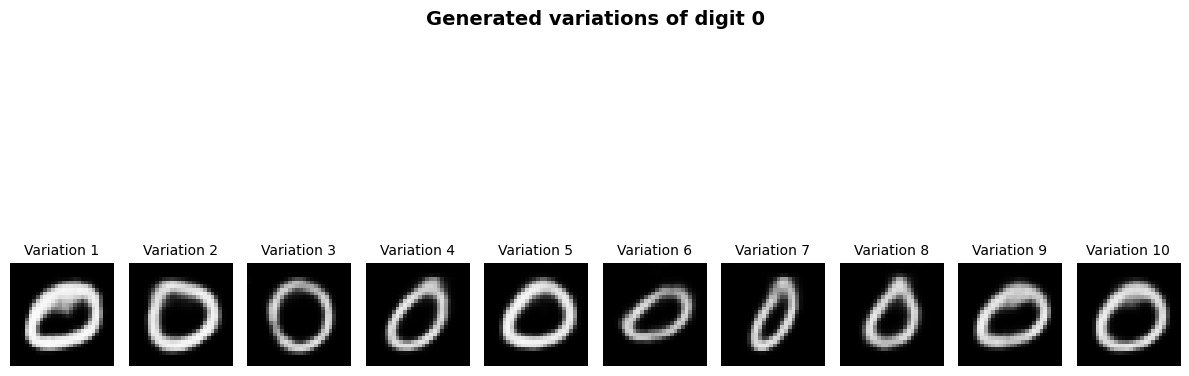

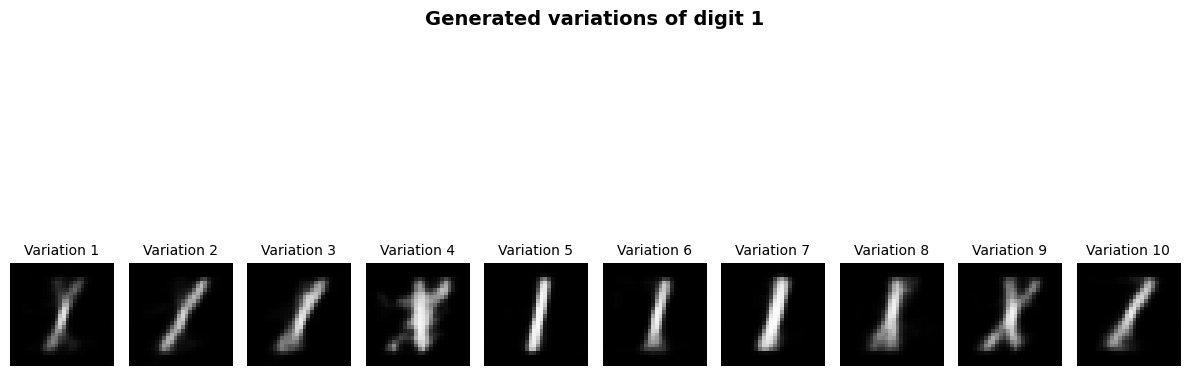

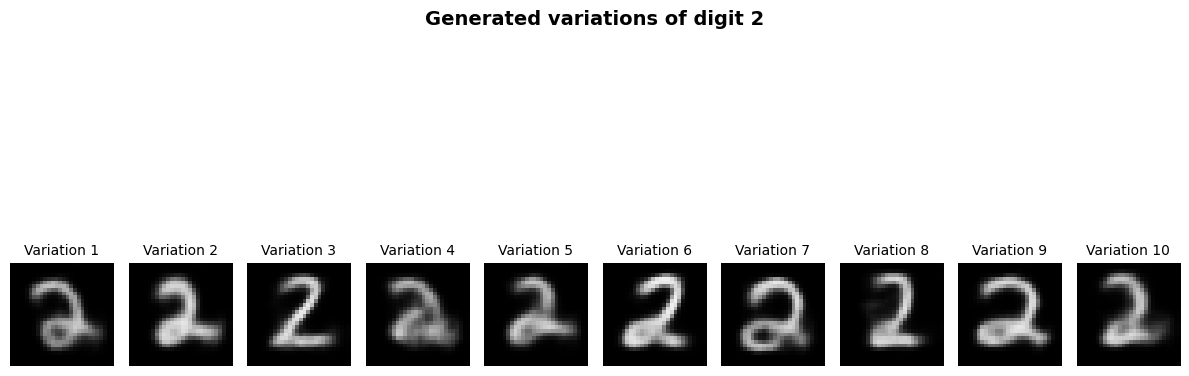

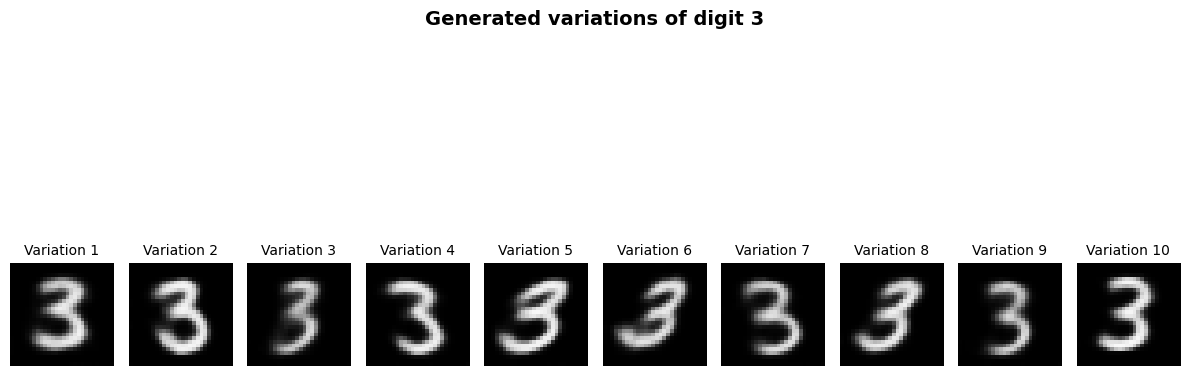

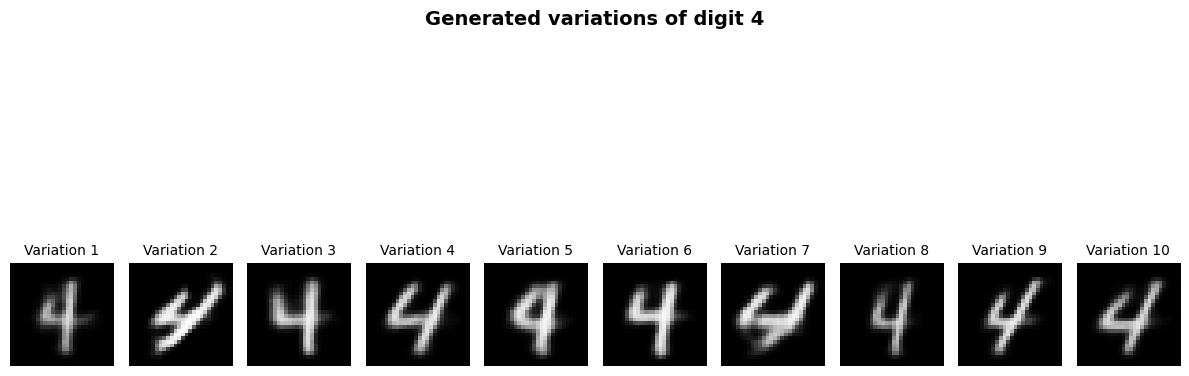

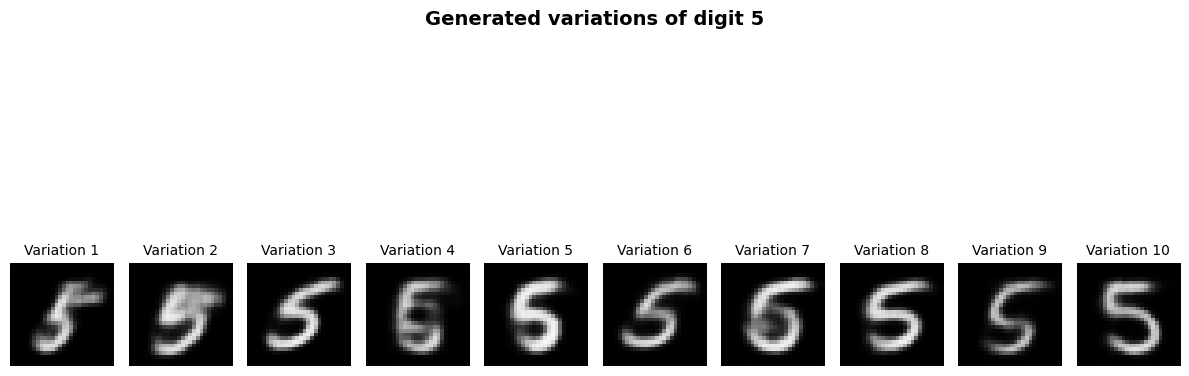

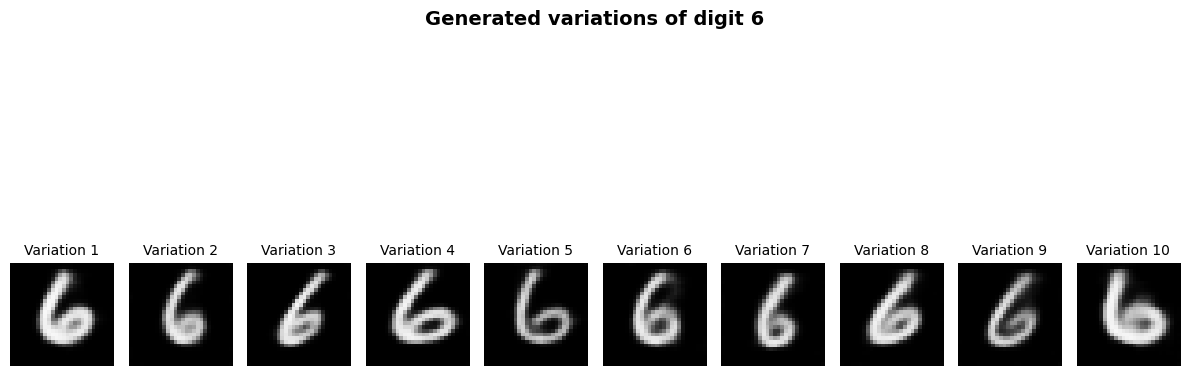

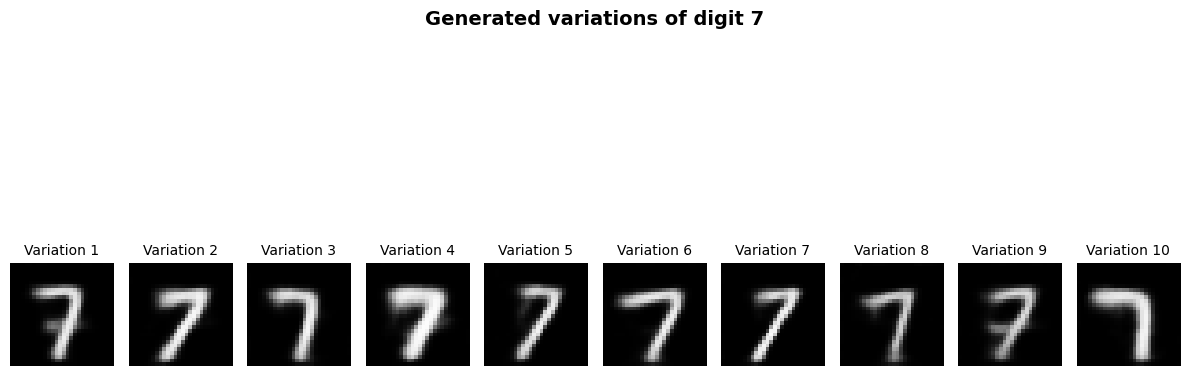

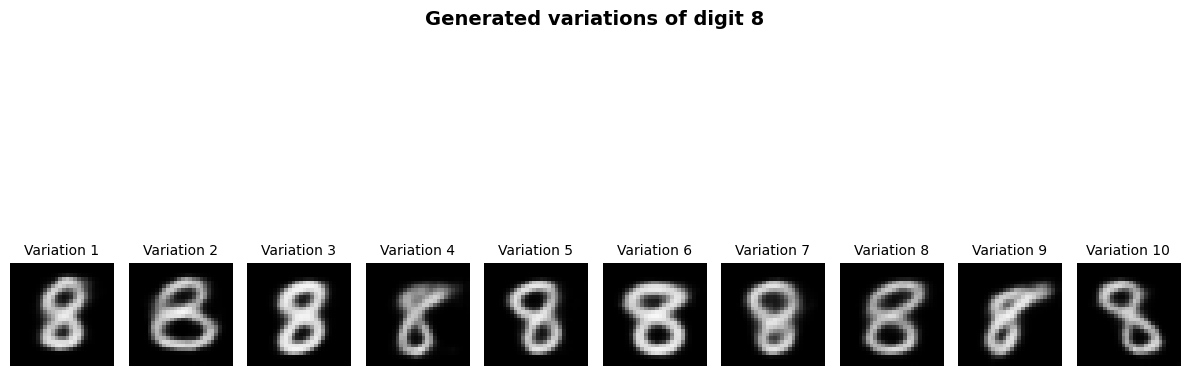

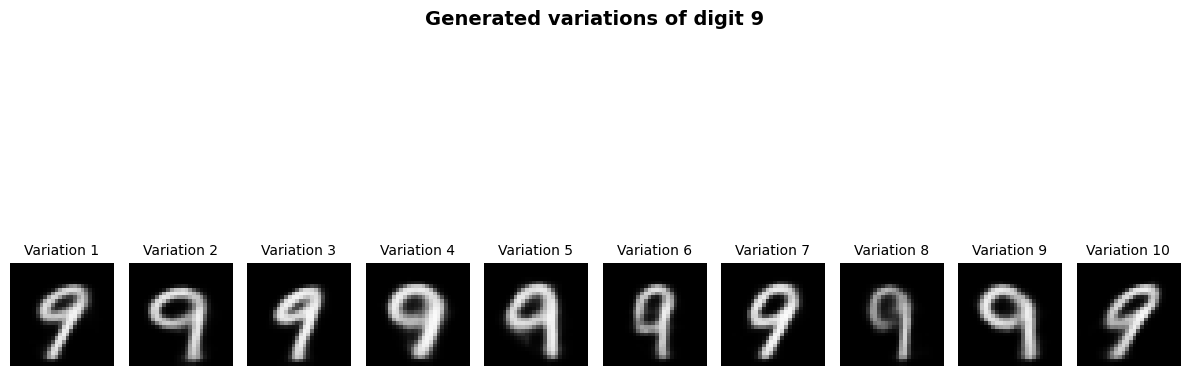

In [ ]:
for r in range(10):
  x = generate_variations(model_v4, label=r, num_samples=10, device=device)

The best model for generating images seems to be  model_v3, having the clearest images followed model_v4.

Model v2 generates images succesfuly but some are disfigured; based on this a constant beta seems to be better for these serires of models.
